In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os

In [4]:
dataframe = pd.read_csv(r'C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\GAME_OVER.csv')

In [6]:
dataframe

,GameSeed,GameName,Round,Event,Tick,Turn,PlayerCount,GameID,OrdinalPosition(Player-1 rank),OrdinalPosition(PlayerName-0),...,RuleCardsUsed(Rule-PushOut),RuleCardsUsed(Rule-PushRequirement),RuleCardsUsed(Rule-Victory),PlayerType(PlayerType-1),PlayerType(PlayerType-0),MarbelsRemoved(Player0removed marbles),MarbelsRemoved(Player1removed marbles),WhoPushedOut(Player0Pushed Marbles),WhoPushedOut(Player1Pushed Marbles),Winner(PlayerIdx)
0,1746059027,MultiverseMarbles,0,GAME_OVER,109,108,2,2,2,Recommended_4,...,"Pushed out marbles return to the center, if it...",You can push your opposing marbles if you use ...,Push out 3 opposing marbles.,Recommended_4_ownColorVictoryHeuristic,Recommended_4,[],[0],[],"[1, 0, 0, 0]",0
1,1717405991,MultiverseMarbles,0,GAME_OVER,98,97,2,3,1,Recommended_4,...,Pushed out marbles are removed from play,You can push opposing marbles if you use more ...,Occupy all goals of your color.,Recommended_4_ownColorVictoryHeuristic,Recommended_4,"[0, 0, 0]",[],"[0, 0, 0]",[],1
2,-815598253,MultiverseMarbles,0,GAME_OVER,73,72,2,4,2,Recommended_4,...,Pushed out marbles return to the center. Remov...,You can push your opposing marbles if you use ...,Occupy 1 goal of each color.,Recommended_4_ownColorVictoryHeuristic,Recommended_4,[],[],"[0, 0]",[],0
3,2110276287,MultiverseMarbles,0,GAME_OVER,34,33,2,5,1,Recommended_4,...,Pushed out marbles are removed from play,You can push opposing marbles if you use fewer...,Occupy 3 non-neighbouring goals.,Recommended_4_ownColorVictoryHeuristic,Recommended_4,[0],[],[0],[],1
4,-2066950591,MultiverseMarbles,0,GAME_OVER,21,20,2,6,2,Recommended_4,...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use equal...,Occupy 1 goal of each color.,Recommended_4_ownColorVictoryHeuristic,Recommended_4,[],[],[],[],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,-1791427606,MultiverseMarbles,0,GAME_OVER,27,26,2,993,2,Recommended_4_pushVictoryHeuristic,...,Pushed out marbles are removed from play,You can push opposing marbles if you use an ev...,Occupy 1 goal of each color.,Recommended_4_ownColorVictoryHeuristic,Recommended_4_pushVictoryHeuristic,[],"[0, 0]",[],"[0, 0]",0
992,1363510825,MultiverseMarbles,0,GAME_OVER,83,82,2,994,2,Recommended_4_pushVictoryHeuristic,...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use fewer...,Occupy 1 goal of each color.,Recommended_4_ownColorVictoryHeuristic,Recommended_4_pushVictoryHeuristic,[],[],[],[],0
993,33308118,MultiverseMarbles,0,GAME_OVER,193,192,2,995,2,Recommended_4_pushVictoryHeuristic,...,"Pushed out marbles return to the center, if it...",You can push your opposing marbles if you use ...,Occupy 3 non-neighbouring goals.,Recommended_4_ownColorVictoryHeuristic,Recommended_4_pushVictoryHeuristic,[],[],[],"[1, 0]",0
994,-1891042671,MultiverseMarbles,0,GAME_OVER,28,27,2,996,1,Recommended_4_pushVictoryHeuristic,...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use an ev...,Occupy 3 non-neighbouring goals.,Recommended_4_ownColorVictoryHeuristic,Recommended_4_pushVictoryHeuristic,[],[],[],[1],1


Saved detailed results to: C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\first player advantage\first_player_advantage_by_rules.csv
Saved processed data to: C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\first player advantage\first_player_advantage_processed.csv
Saved plot to: C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\first player advantage\first_player_advantage_plot.png
Overall first player win rate: 50.00% (n=996)
Saved overall statistics to: C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\first player advantage\first_player_advantage_overall.csv
Saved detailed results to: C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\first player advantage\first_player_advantage_by_rules.csv
Saved processed data to: C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\first player advantage\first_player_advantage_processed.csv
Saved plot to: C:\Users\Joshua\Documents\GitSources\T

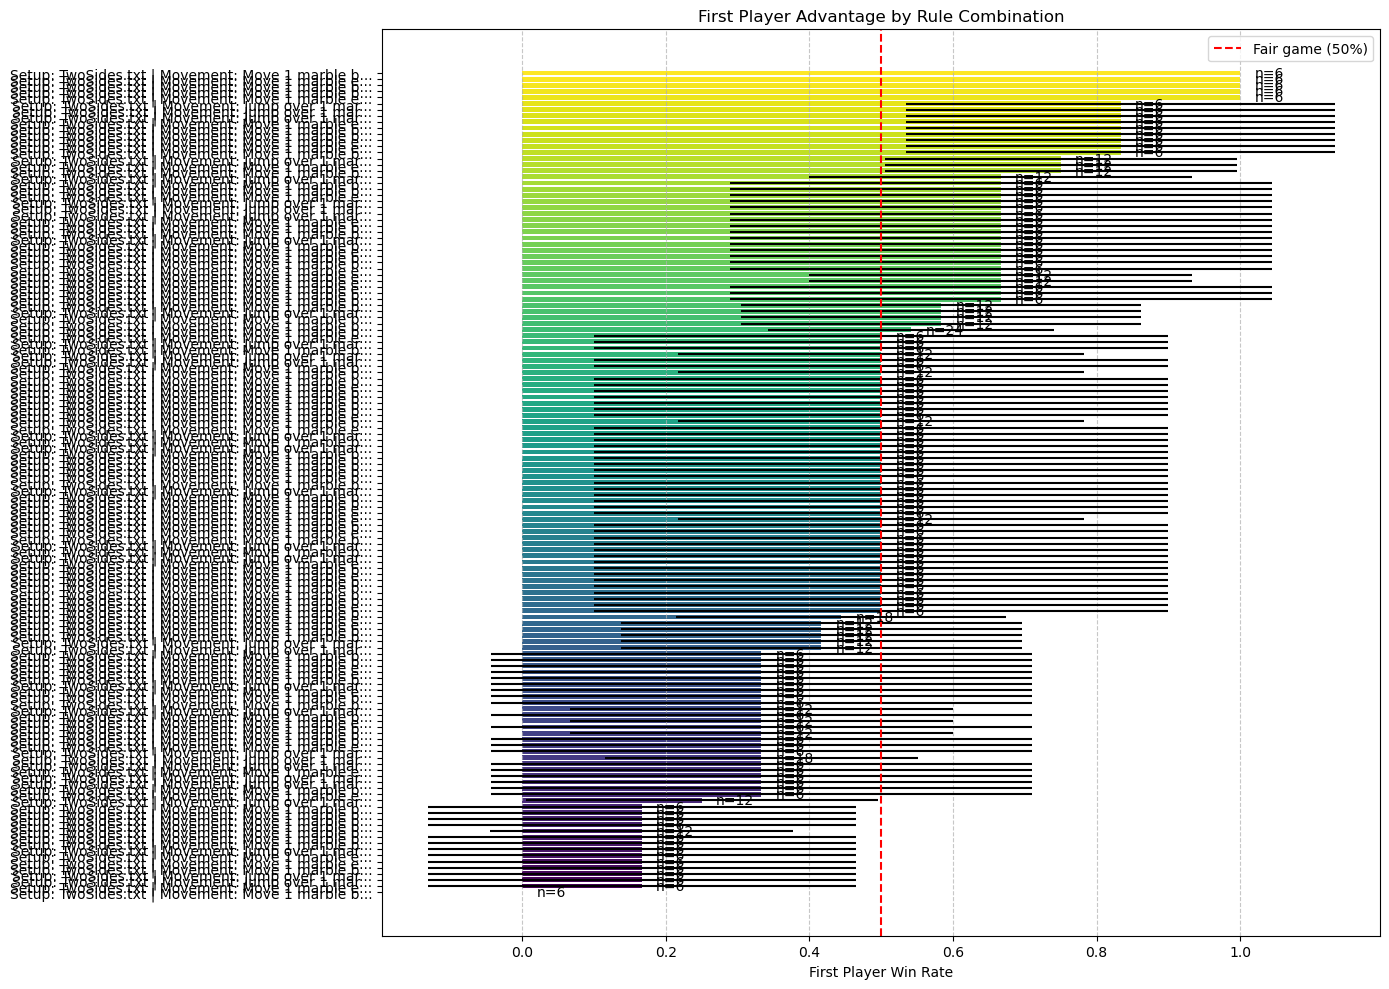

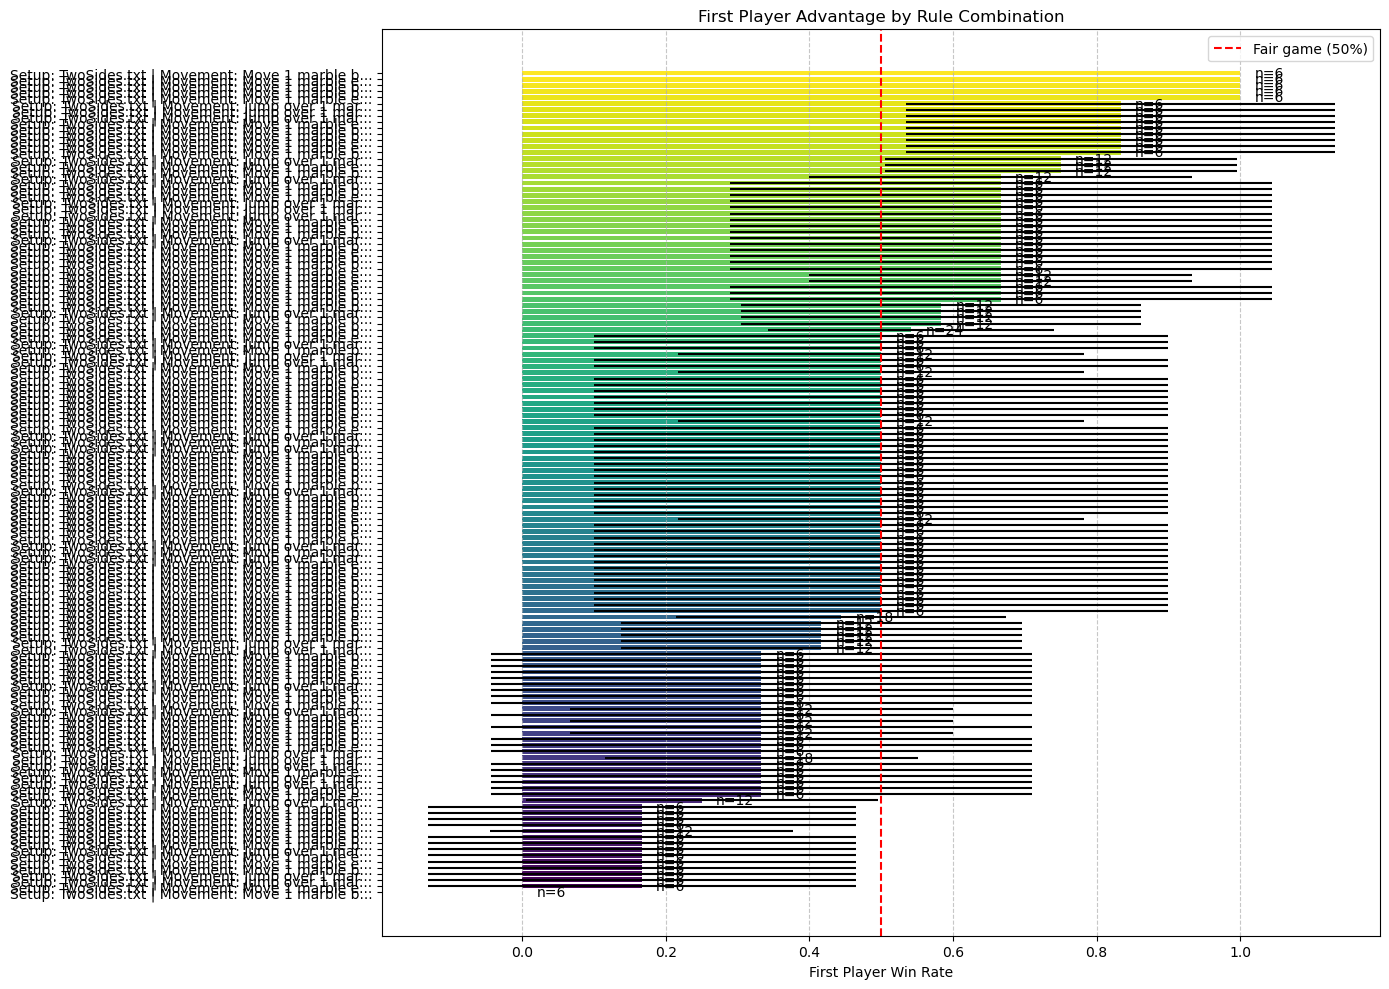

In [20]:
# Assuming your dataframe is called 'dataframe'

def analyze_first_player_advantage(df, output_dir):
    # Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")
    
    # Extract rule columns
    rule_columns = [col for col in df.columns if col.startswith('RuleCardsUsed')]
    
    # Convert rule columns to categorical format for analysis
    # Create a copy to avoid modifying the original dataframe
    analysis_df = df.copy()
    
    # Create binary columns for each rule type
    for rule_col in rule_columns:
        unique_rules = df[rule_col].unique()
        # Skip NaN values
        unique_rules = [r for r in unique_rules if isinstance(r, str)]
        
        for rule in unique_rules:
            # Create a column name based on the rule category and specific rule
            rule_category = rule_col.split('(Rule-')[1].replace(')', '')
            column_name = f"{rule_category}_{rule}"
            # Create binary indicator
            analysis_df[column_name] = (df[rule_col] == rule).astype(int)
    
    # Group by all binary rule columns
    binary_rule_cols = [col for col in analysis_df.columns 
                        if any(col.startswith(f"{cat}_") for cat in 
                              ['Setup', 'Movement', 'Push', 'PushOut', 'PushRequirement', 'Victory'])]
    
    # Check if we have binary rule columns
    if not binary_rule_cols:
        print("No binary rule columns created. Check rule column format.")
        return
    
    # Group by rule combinations
    grouped = analysis_df.groupby(binary_rule_cols)
    
    # Calculate win rate for player 0 (first player)
    results = grouped.agg(
        total_games=('Winner(PlayerIdx)', 'count'),
        player0_wins=('Winner(PlayerIdx)', lambda x: (x == 0).sum()),
    )
    
    # Calculate win rate
    results['player0_win_rate'] = results['player0_wins'] / results['total_games']
    
    # Only include combinations with a minimum number of games
    min_games = 5  # Adjust as needed
    results = results[results['total_games'] >= min_games]
    
    # Sort by win rate
    results = results.sort_values('player0_win_rate', ascending=False)
    
    # Save the detailed results to CSV
    results_csv_path = os.path.join(output_dir, 'first_player_advantage_by_rules.csv')
    results.to_csv(results_csv_path)
    print(f"Saved detailed results to: {results_csv_path}")
    
    # Reset index for plotting
    results_reset = results.reset_index()
    
    # Save the processed data to CSV
    processed_csv_path = os.path.join(output_dir, 'first_player_advantage_processed.csv')
    results_reset.to_csv(processed_csv_path, index=False)
    print(f"Saved processed data to: {processed_csv_path}")
    
    # Create readable rule combination labels
    rule_combinations = []
    for _, row in results_reset.iterrows():
        active_rules = []
        for rule_col in binary_rule_cols:
            if row[rule_col] == 1:
                rule_name = rule_col.split('_', 1)[1] if '_' in rule_col else rule_col
                rule_category = rule_col.split('_')[0]
                active_rules.append(f"{rule_category}: {rule_name}")
        
        combo_name = " | ".join(active_rules) if active_rules else "No specific rules"
        if len(combo_name) > 50:  # Truncate very long names
            combo_name = combo_name[:47] + "..."
        rule_combinations.append(combo_name)
    
    # Calculate confidence intervals using binomial distribution
    z = 1.96  # 95% confidence
    results_reset['ci'] = z * np.sqrt((results_reset['player0_win_rate'] * 
                                     (1 - results_reset['player0_win_rate'])) / 
                                     results_reset['total_games'])
    
    # Sort by win rate for better visualization
    sorted_indices = results_reset['player0_win_rate'].argsort()
    sorted_win_rates = results_reset['player0_win_rate'].iloc[sorted_indices]
    sorted_ci = results_reset['ci'].iloc[sorted_indices]
    sorted_labels = [rule_combinations[i] for i in sorted_indices]
    
    # Plot with confidence intervals
    plt.figure(figsize=(14, 10))
    bars = plt.barh(range(len(sorted_win_rates)), sorted_win_rates, xerr=sorted_ci, 
                   color=plt.cm.viridis(np.linspace(0, 1, len(sorted_win_rates))))
    
    plt.axvline(x=0.5, color='r', linestyle='--', label='Fair game (50%)')
    plt.yticks(range(len(sorted_labels)), sorted_labels)
    plt.xlabel('First Player Win Rate')
    plt.title('First Player Advantage by Rule Combination')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add game count annotations
    for i, (win_rate, count) in enumerate(zip(sorted_win_rates, 
                                             results_reset['total_games'].iloc[sorted_indices])):
        plt.text(win_rate + 0.02, i, f"n={count}", va='center')
    
    plt.tight_layout()
    plt.legend()
    
    # Save the plot
    plot_path = os.path.join(output_dir, 'first_player_advantage_plot.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Saved plot to: {plot_path}")
    
    # Calculate overall first player advantage
    overall_win_rate = (df['Winner(PlayerIdx)'] == 0).mean()
    overall_games = len(df)
    print(f"Overall first player win rate: {overall_win_rate:.2%} (n={overall_games})")
    
    # Save overall statistics
    overall_stats = pd.DataFrame({
        'Metric': ['Overall First Player Win Rate', 'Total Games'],
        'Value': [overall_win_rate, overall_games]
    })
    overall_stats_path = os.path.join(output_dir, 'first_player_advantage_overall.csv')
    overall_stats.to_csv(overall_stats_path, index=False)
    print(f"Saved overall statistics to: {overall_stats_path}")
    
    return results

# Define the output directory
output_dir = r"C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\first player advantage"

# Run the analysis and save the results
rule_advantage_results = analyze_first_player_advantage(dataframe, output_dir)
# Run the analysis
rule_advantage_results = analyze_first_player_advantage(dataframe, output_dir)
print(rule_advantage_results)

In [10]:
def analyze_polarized_rule_combinations(df, output_dir, high_threshold=0.7, low_threshold=0.3, min_games=5):
    """
    Identify rule combinations that produce highly polarized results (strongly favoring either player).
    
    Parameters:
    - df: DataFrame containing game data
    - output_dir: Directory to save results
    - high_threshold: Win rate threshold for first player advantage (default: 0.7)
    - low_threshold: Win rate threshold for second player advantage (default: 0.3)
    - min_games: Minimum number of games required for a rule combination to be considered
    """
    # Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")
    
    # Extract rule columns
    rule_columns = [col for col in df.columns if col.startswith('RuleCardsUsed')]
    
    # Convert rule columns to categorical format for analysis
    analysis_df = df.copy()
    
    # Create binary columns for each rule type
    for rule_col in rule_columns:
        unique_rules = df[rule_col].unique()
        # Skip NaN values
        unique_rules = [r for r in unique_rules if isinstance(r, str)]
        
        for rule in unique_rules:
            # Create a column name based on the rule category and specific rule
            rule_category = rule_col.split('(Rule-')[1].replace(')', '')
            column_name = f"{rule_category}_{rule}"
            # Create binary indicator
            analysis_df[column_name] = (df[rule_col] == rule).astype(int)
    
    # Group by all binary rule columns
    binary_rule_cols = [col for col in analysis_df.columns 
                        if any(col.startswith(f"{cat}_") for cat in 
                              ['Setup', 'Movement', 'Push', 'PushOut', 'PushRequirement', 'Victory'])]
    
    # Check if we have binary rule columns
    if not binary_rule_cols:
        print("No binary rule columns created. Check rule column format.")
        return
    
    # Group by rule combinations
    grouped = analysis_df.groupby(binary_rule_cols)
    
    # Calculate win rate for player 0 (first player)
    results = grouped.agg(
        total_games=('Winner(PlayerIdx)', 'count'),
        player0_wins=('Winner(PlayerIdx)', lambda x: (x == 0).sum()),
    )
    
    # Calculate win rate
    results['player0_win_rate'] = results['player0_wins'] / results['total_games']
    
    # Only include combinations with a minimum number of games
    results = results[results['total_games'] >= min_games]
    
    # Calculate confidence intervals
    z = 1.96  # 95% confidence
    results['ci_lower'] = results['player0_win_rate'] - z * np.sqrt(
        (results['player0_win_rate'] * (1 - results['player0_win_rate'])) / results['total_games'])
    results['ci_upper'] = results['player0_win_rate'] + z * np.sqrt(
        (results['player0_win_rate'] * (1 - results['player0_win_rate'])) / results['total_games'])
    
    # Identify polarized combinations
    high_advantage = results[(results['player0_win_rate'] >= high_threshold)]
    low_advantage = results[(results['player0_win_rate'] <= low_threshold)]
    
    # Sort by win rate
    high_advantage = high_advantage.sort_values('player0_win_rate', ascending=False)
    low_advantage = low_advantage.sort_values('player0_win_rate', ascending=True)
    
    # Create a function to generate readable rule descriptions
    def get_rule_description(rule_combination):
        active_rules = {}
        for col in binary_rule_cols:
            if rule_combination[col] == 1:
                category = col.split('_')[0]
                rule = col.split('_', 1)[1] if '_' in col else col
                if category not in active_rules:
                    active_rules[category] = []
                active_rules[category].append(rule)
        
        description = []
        for category, rules in active_rules.items():
            description.append(f"{category}: {', '.join(rules)}")
        
        return " | ".join(description) if description else "No specific rules"
    
    # Add readable descriptions
    high_advantage_reset = high_advantage.reset_index()
    low_advantage_reset = low_advantage.reset_index()
    
    high_advantage_reset['rule_description'] = high_advantage_reset.apply(
        lambda row: get_rule_description({col: row[col] for col in binary_rule_cols}), axis=1)
    
    low_advantage_reset['rule_description'] = low_advantage_reset.apply(
        lambda row: get_rule_description({col: row[col] for col in binary_rule_cols}), axis=1)
    
    # Save results to CSV
    high_advantage_path = os.path.join(output_dir, 'first_player_high_advantage.csv')
    low_advantage_path = os.path.join(output_dir, 'first_player_low_advantage.csv')
    
    high_advantage_reset.to_csv(high_advantage_path, index=False)
    low_advantage_reset.to_csv(low_advantage_path, index=False)
    
    print(f"Saved high advantage combinations (>={high_threshold*100}%) to: {high_advantage_path}")
    print(f"Saved low advantage combinations (<={low_threshold*100}%) to: {low_advantage_path}")
    
    # Create visualizations
    plt.figure(figsize=(14, 10))
    
    # Plot for high advantage combinations
    if len(high_advantage_reset) > 0:
        plt.subplot(2, 1, 1)
        bars = plt.barh(range(len(high_advantage_reset)), 
                       high_advantage_reset['player0_win_rate'],
                       xerr=[high_advantage_reset['player0_win_rate'] - high_advantage_reset['ci_lower'], 
                             high_advantage_reset['ci_upper'] - high_advantage_reset['player0_win_rate']],
                       color='darkred')
        
        plt.axvline(x=0.5, color='black', linestyle='--', label='Fair game (50%)')
        plt.axvline(x=high_threshold, color='red', linestyle='-', label=f'{high_threshold*100}% threshold')
        plt.yticks(range(len(high_advantage_reset)), 
                  [f"{desc[:50]}... (n={n})" if len(desc) > 50 else f"{desc} (n={n})" 
                   for desc, n in zip(high_advantage_reset['rule_description'], 
                                     high_advantage_reset['total_games'])])
        plt.xlabel('First Player Win Rate')
        plt.title(f'Rule Combinations with High First Player Advantage (>={high_threshold*100}%)')
        plt.xlim(0.4, 1.0)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.legend()

Saved high advantage combinations (>=70.0%) to: C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\first_player_high_advantage.csv
Saved low advantage combinations (<=30.0%) to: C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\first_player_low_advantage.csv


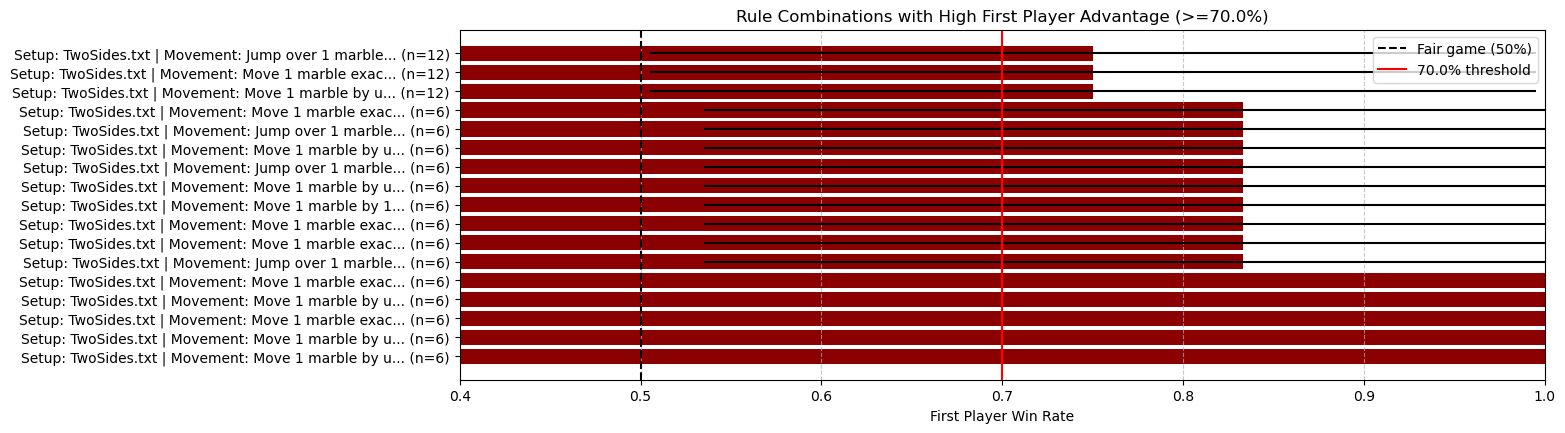

In [16]:
analyze_polarized_rule_combinations(dataframe,r"C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment")



--- Analysis for SETUP rules ---
Win rates for the first player (player0) by setup rule:
     rule_setup  player0_win_rate
0  TwoSides.txt               0.5


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby(f'rule_{rule_type}').apply(


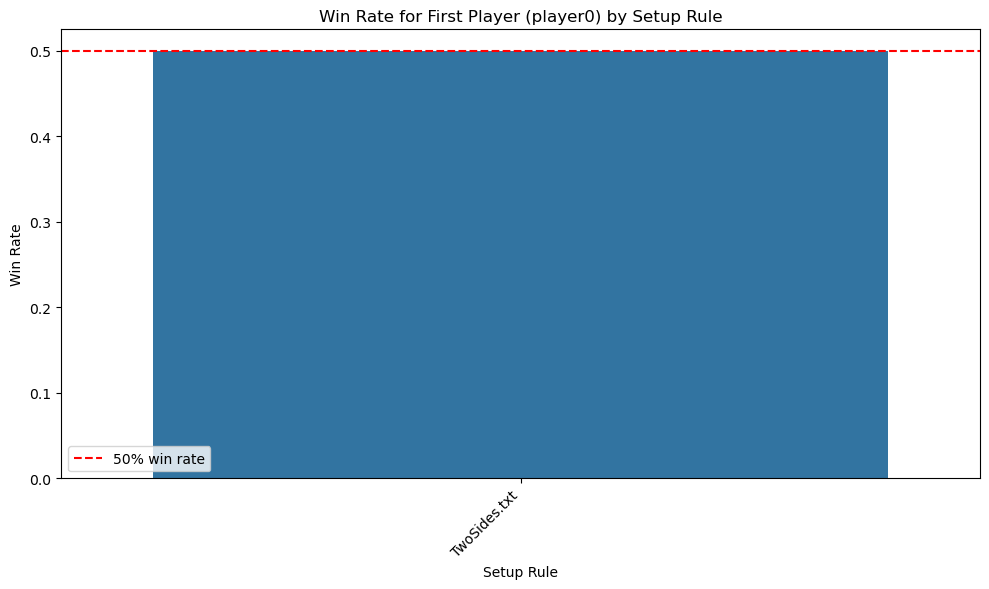


--- Analysis for MOVEMENT rules ---
Win rates for the first player (player0) by movement rule:
                                       rule_movement  player0_win_rate
2  Move 1 marble by up to 3 spaces in any directi...          0.532520
3   Move 1 marble exactly 2 spaces in any direction.          0.530303
0  Jump over 1 marble or blocker or move a marble...          0.479675
1         Move 1 marble by 1 space in any direction.          0.454167


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby(f'rule_{rule_type}').apply(


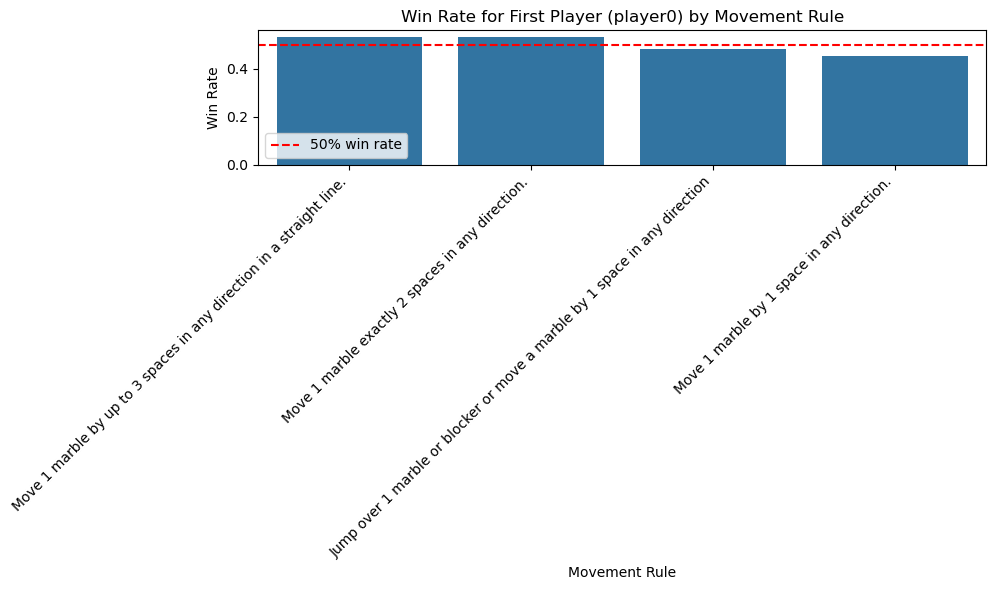


--- Analysis for PUSH rules ---
Win rates for the first player (player0) by push rule:
                                           rule_push  player0_win_rate
0  Push a column of marbles by 1 space in any dir...               0.5


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby(f'rule_{rule_type}').apply(


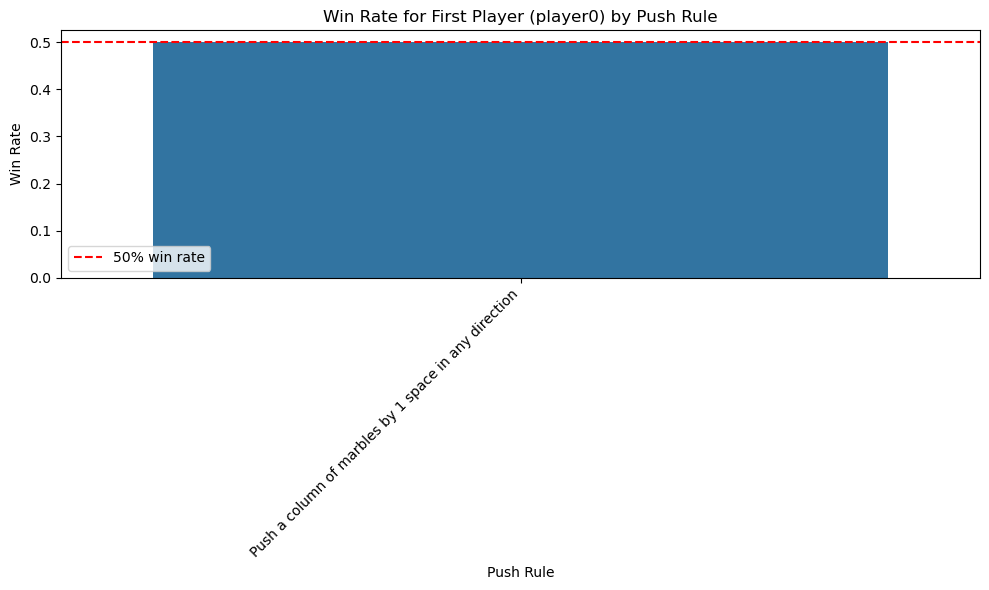


--- Analysis for PUSHOUT rules ---
Win rates for the first player (player0) by pushout rule:
                                        rule_pushout  player0_win_rate
2  Pushed out marbles return to the center. Remov...          0.512121
0           Pushed out marbles are removed from play          0.500000
1  Pushed out marbles return to the center, if it...          0.487654


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby(f'rule_{rule_type}').apply(


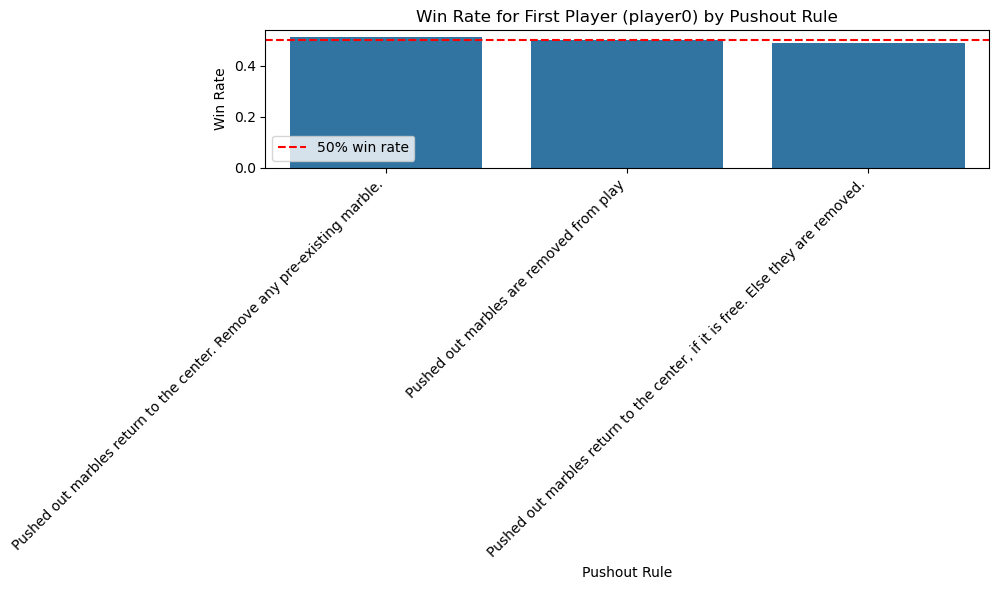


--- Analysis for PUSHREQUIREMENT rules ---
Win rates for the first player (player0) by pushrequirement rule:
                                rule_pushrequirement  player0_win_rate
6  You can push your opposing marbles if you use ...          0.587719
0  You can push opposing marbles if you use an ev...          0.530864
5  You can push opposing marbles if you use more ...          0.520000
3  You can push opposing marbles if you use fewer...          0.500000
4  You can push opposing marbles if you use more ...          0.493827
2  You can push opposing marbles if you use fewer...          0.448718
1  You can push opposing marbles if you use equal...          0.431818


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby(f'rule_{rule_type}').apply(
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


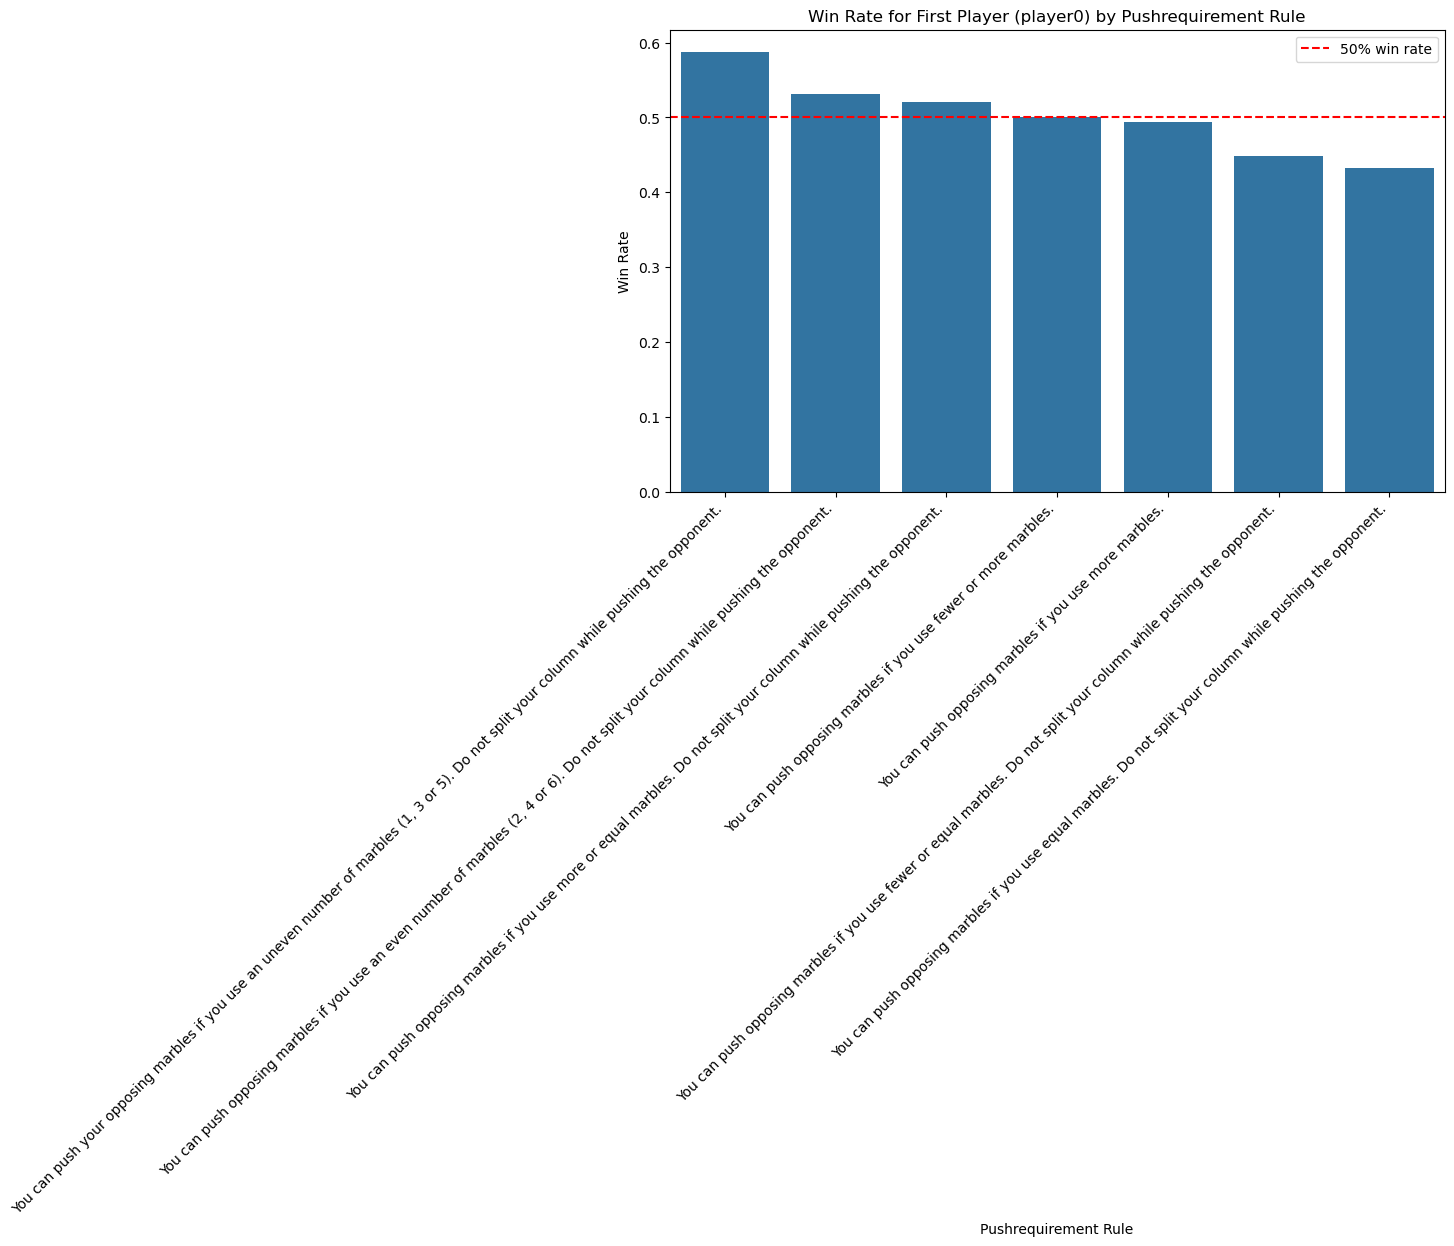


--- Analysis for VICTORY rules ---
Win rates for the first player (player0) by victory rule:
                       rule_victory  player0_win_rate
0      Occupy 1 goal of each color.          0.545752
1  Occupy 3 non-neighbouring goals.          0.521930
2   Occupy all goals of your color.          0.512195
3      Push out 3 opposing marbles.          0.398148


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby(f'rule_{rule_type}').apply(


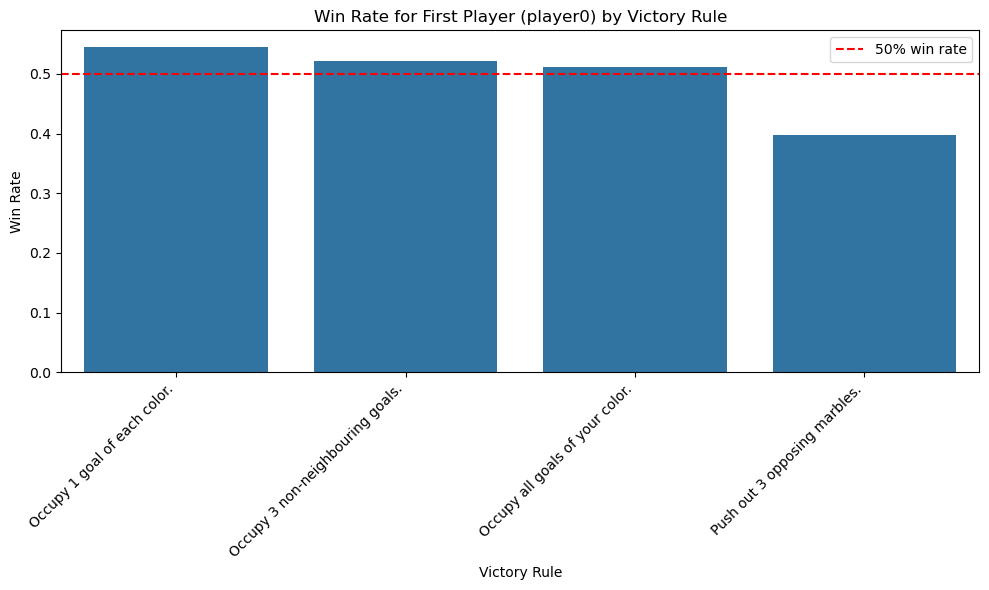


--- Analysis for RULE PAIRS ---

--- Analysis for SETUP vs MOVEMENT rule combinations ---
Win rates for the first player (player0) by setup + movement combination:
                                           rule_pair  player0_win_rate  count
2  TwoSides.txt + Move 1 marble by up to 3 spaces...          0.532520    246
3  TwoSides.txt + Move 1 marble exactly 2 spaces ...          0.530303    264
0  TwoSides.txt + Jump over 1 marble or blocker o...          0.479675    246
1  TwoSides.txt + Move 1 marble by 1 space in any...          0.454167    240


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


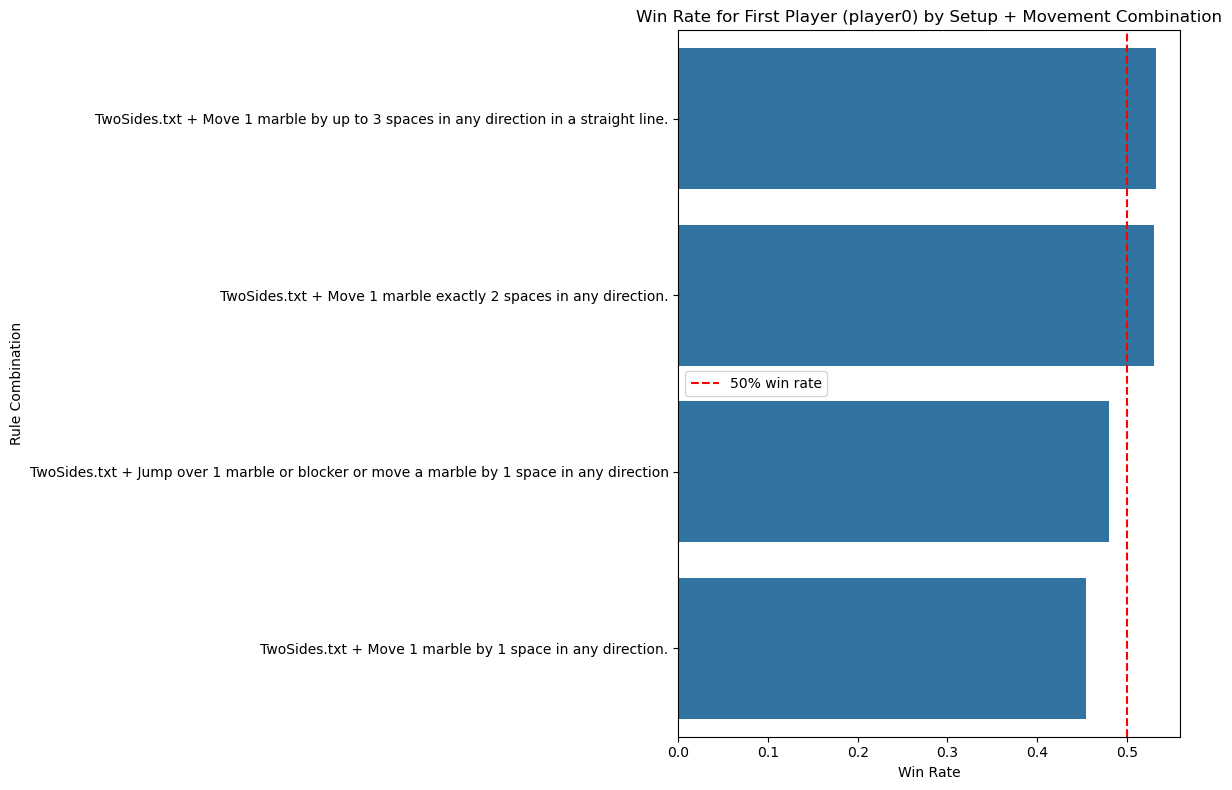


--- Analysis for SETUP vs PUSH rule combinations ---
Win rates for the first player (player0) by setup + push combination:
                                           rule_pair  player0_win_rate  count
0  TwoSides.txt + Push a column of marbles by 1 s...               0.5    996


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


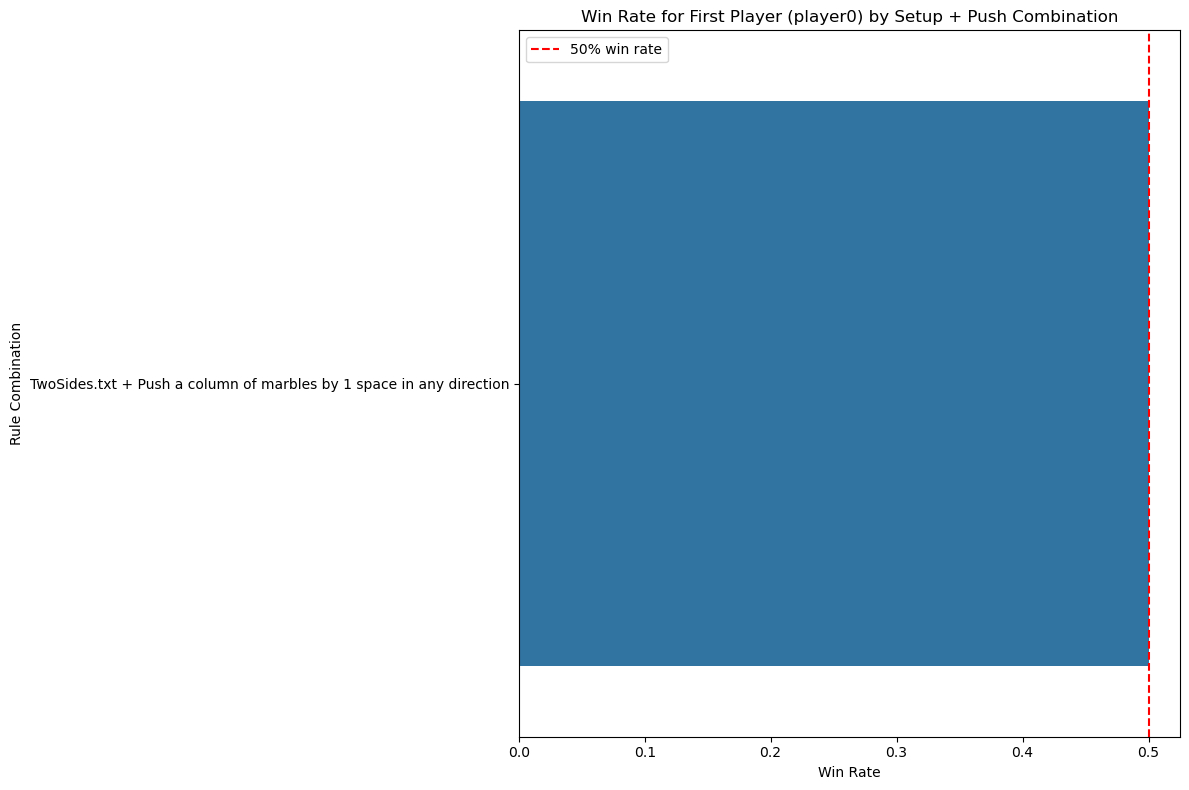


--- Analysis for SETUP vs PUSHOUT rule combinations ---
Win rates for the first player (player0) by setup + pushout combination:
                                           rule_pair  player0_win_rate  count
2  TwoSides.txt + Pushed out marbles return to th...          0.512121    330
0  TwoSides.txt + Pushed out marbles are removed ...          0.500000    342
1  TwoSides.txt + Pushed out marbles return to th...          0.487654    324


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


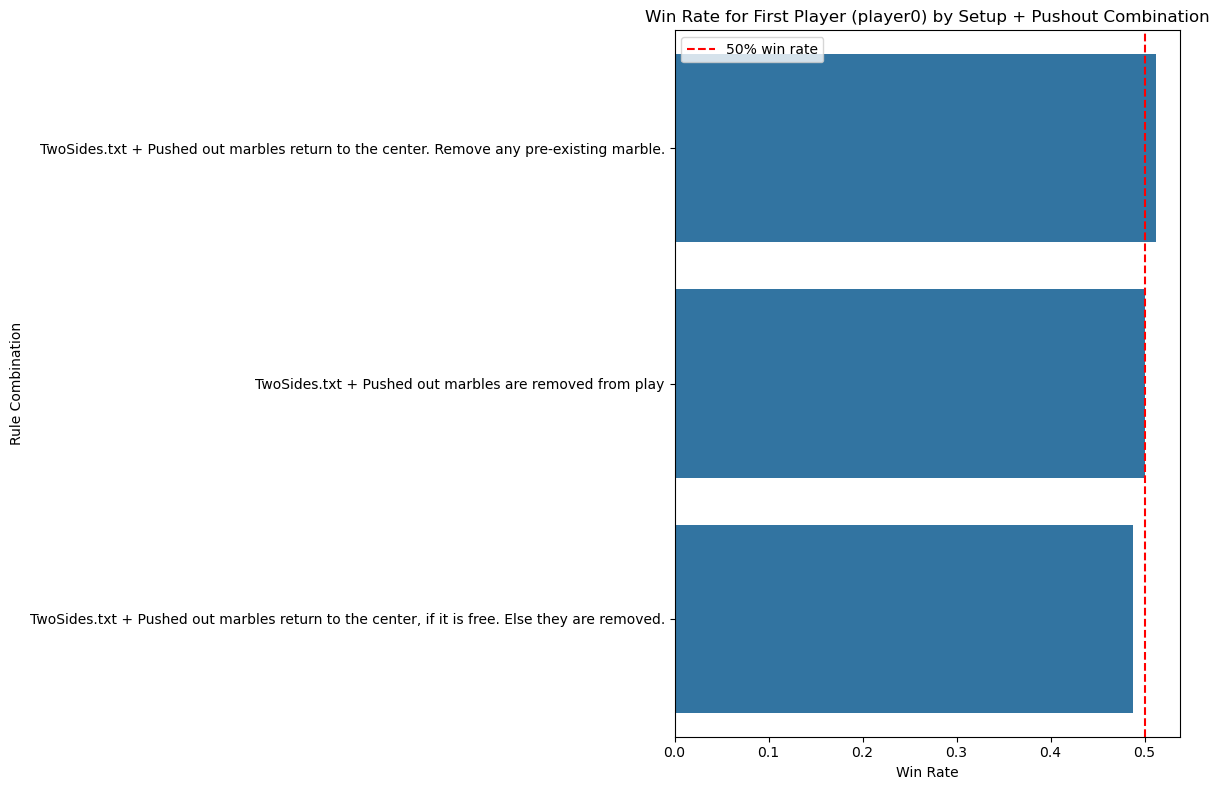


--- Analysis for SETUP vs PUSHREQUIREMENT rule combinations ---
Win rates for the first player (player0) by setup + pushrequirement combination:
                                           rule_pair  player0_win_rate  count
6  TwoSides.txt + You can push your opposing marb...          0.587719    114
0  TwoSides.txt + You can push opposing marbles i...          0.530864    162
5  TwoSides.txt + You can push opposing marbles i...          0.520000    150
3  TwoSides.txt + You can push opposing marbles i...          0.500000    120
4  TwoSides.txt + You can push opposing marbles i...          0.493827    162
2  TwoSides.txt + You can push opposing marbles i...          0.448718    156
1  TwoSides.txt + You can push opposing marbles i...          0.431818    132


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


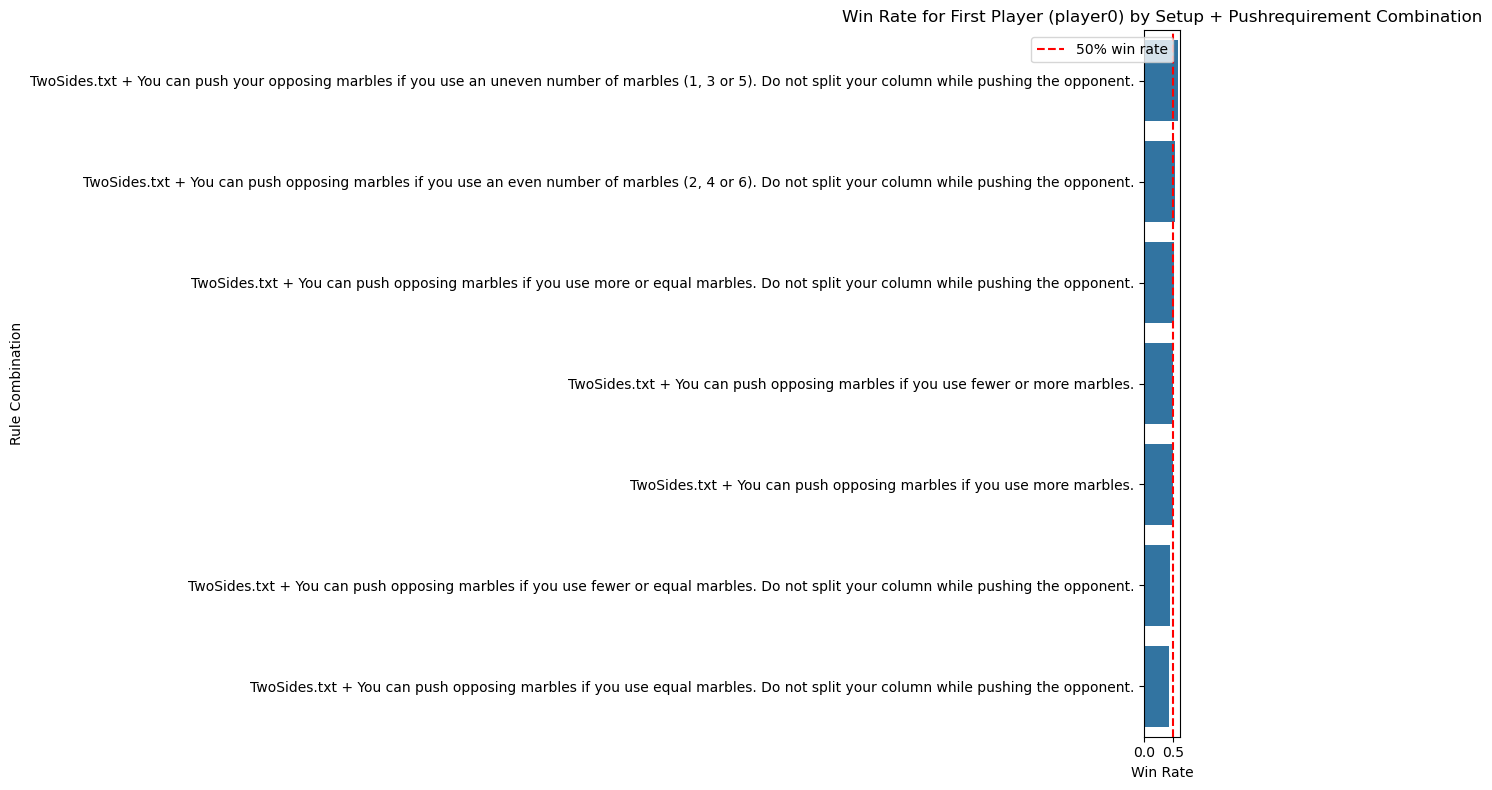


--- Analysis for SETUP vs VICTORY rule combinations ---
Win rates for the first player (player0) by setup + victory combination:
                                         rule_pair  player0_win_rate  count
0      TwoSides.txt + Occupy 1 goal of each color.          0.545752    306
1  TwoSides.txt + Occupy 3 non-neighbouring goals.          0.521930    228
2   TwoSides.txt + Occupy all goals of your color.          0.512195    246
3      TwoSides.txt + Push out 3 opposing marbles.          0.398148    216


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


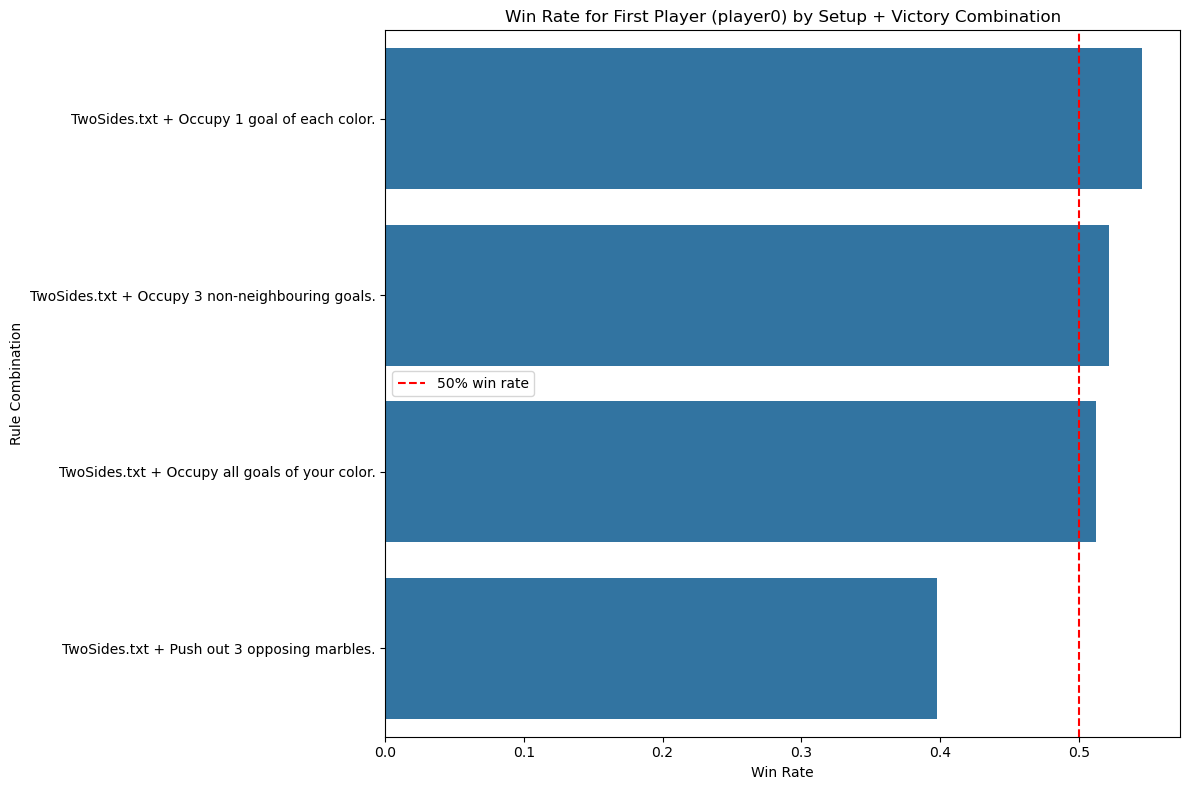


--- Analysis for MOVEMENT vs PUSH rule combinations ---
Win rates for the first player (player0) by movement + push combination:
                                           rule_pair  player0_win_rate  count
2  Move 1 marble by up to 3 spaces in any directi...          0.532520    246
3  Move 1 marble exactly 2 spaces in any directio...          0.530303    264
0  Jump over 1 marble or blocker or move a marble...          0.479675    246
1  Move 1 marble by 1 space in any direction. + P...          0.454167    240


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


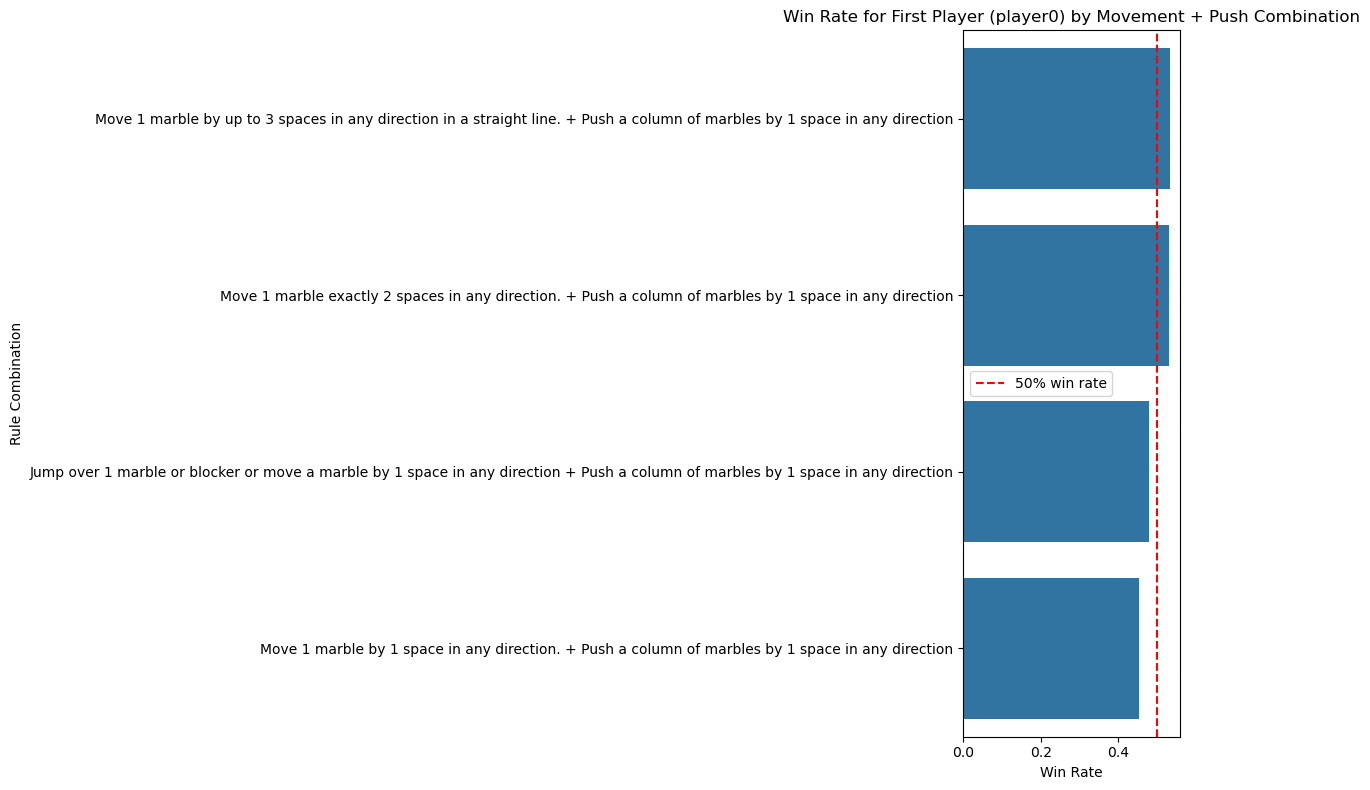


--- Analysis for MOVEMENT vs PUSHOUT rule combinations ---
Win rates for the first player (player0) by movement + pushout combination:
                                            rule_pair  player0_win_rate  count
6   Move 1 marble by up to 3 spaces in any directi...          0.552083     96
11  Move 1 marble exactly 2 spaces in any directio...          0.541667     96
8   Move 1 marble by up to 3 spaces in any directi...          0.531250     96
10  Move 1 marble exactly 2 spaces in any directio...          0.529412    102
9   Move 1 marble exactly 2 spaces in any directio...          0.515152     66
5   Move 1 marble by 1 space in any direction. + P...          0.512821     78
0   Jump over 1 marble or blocker or move a marble...          0.500000     78
7   Move 1 marble by up to 3 spaces in any directi...          0.500000     54
1   Jump over 1 marble or blocker or move a marble...          0.490741    108
3   Move 1 marble by 1 space in any direction. + P...          0.441176   

C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


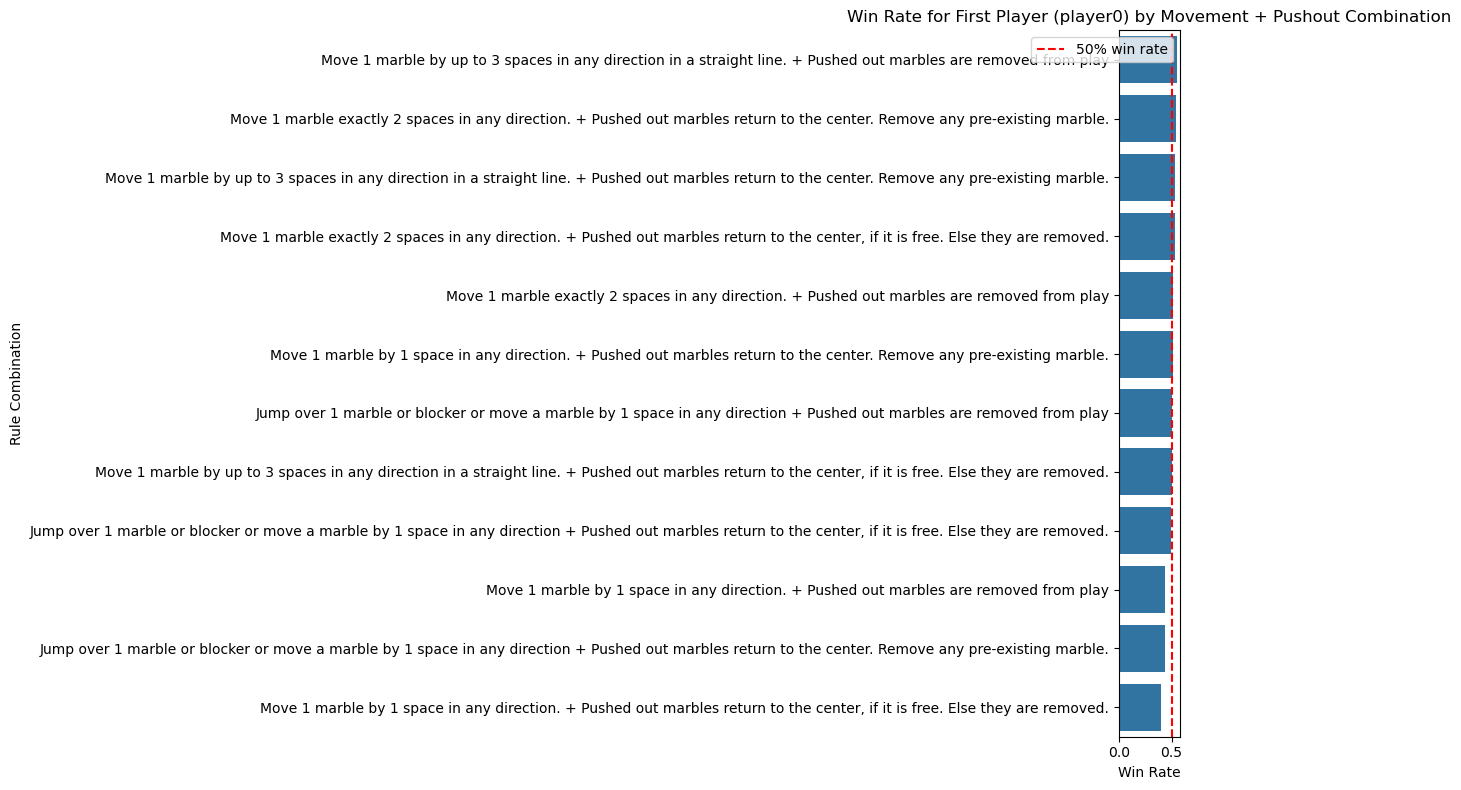


--- Analysis for MOVEMENT vs PUSHREQUIREMENT rule combinations ---
Win rates for the first player (player0) by movement + pushrequirement combination:
                                            rule_pair  player0_win_rate  count
11  Move 1 marble by 1 space in any direction. + Y...          0.666667     12
20  Move 1 marble by up to 3 spaces in any directi...          0.645833     48
19  Move 1 marble by up to 3 spaces in any directi...          0.642857     42
23  Move 1 marble exactly 2 spaces in any directio...          0.638889     36
17  Move 1 marble by up to 3 spaces in any directi...          0.633333     30
21  Move 1 marble exactly 2 spaces in any directio...          0.625000     48
26  Move 1 marble exactly 2 spaces in any directio...          0.583333     36
24  Move 1 marble exactly 2 spaces in any directio...          0.583333     24
6   Jump over 1 marble or blocker or move a marble...          0.583333     12
13  Move 1 marble by 1 space in any direction. + Y...     

C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:92: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


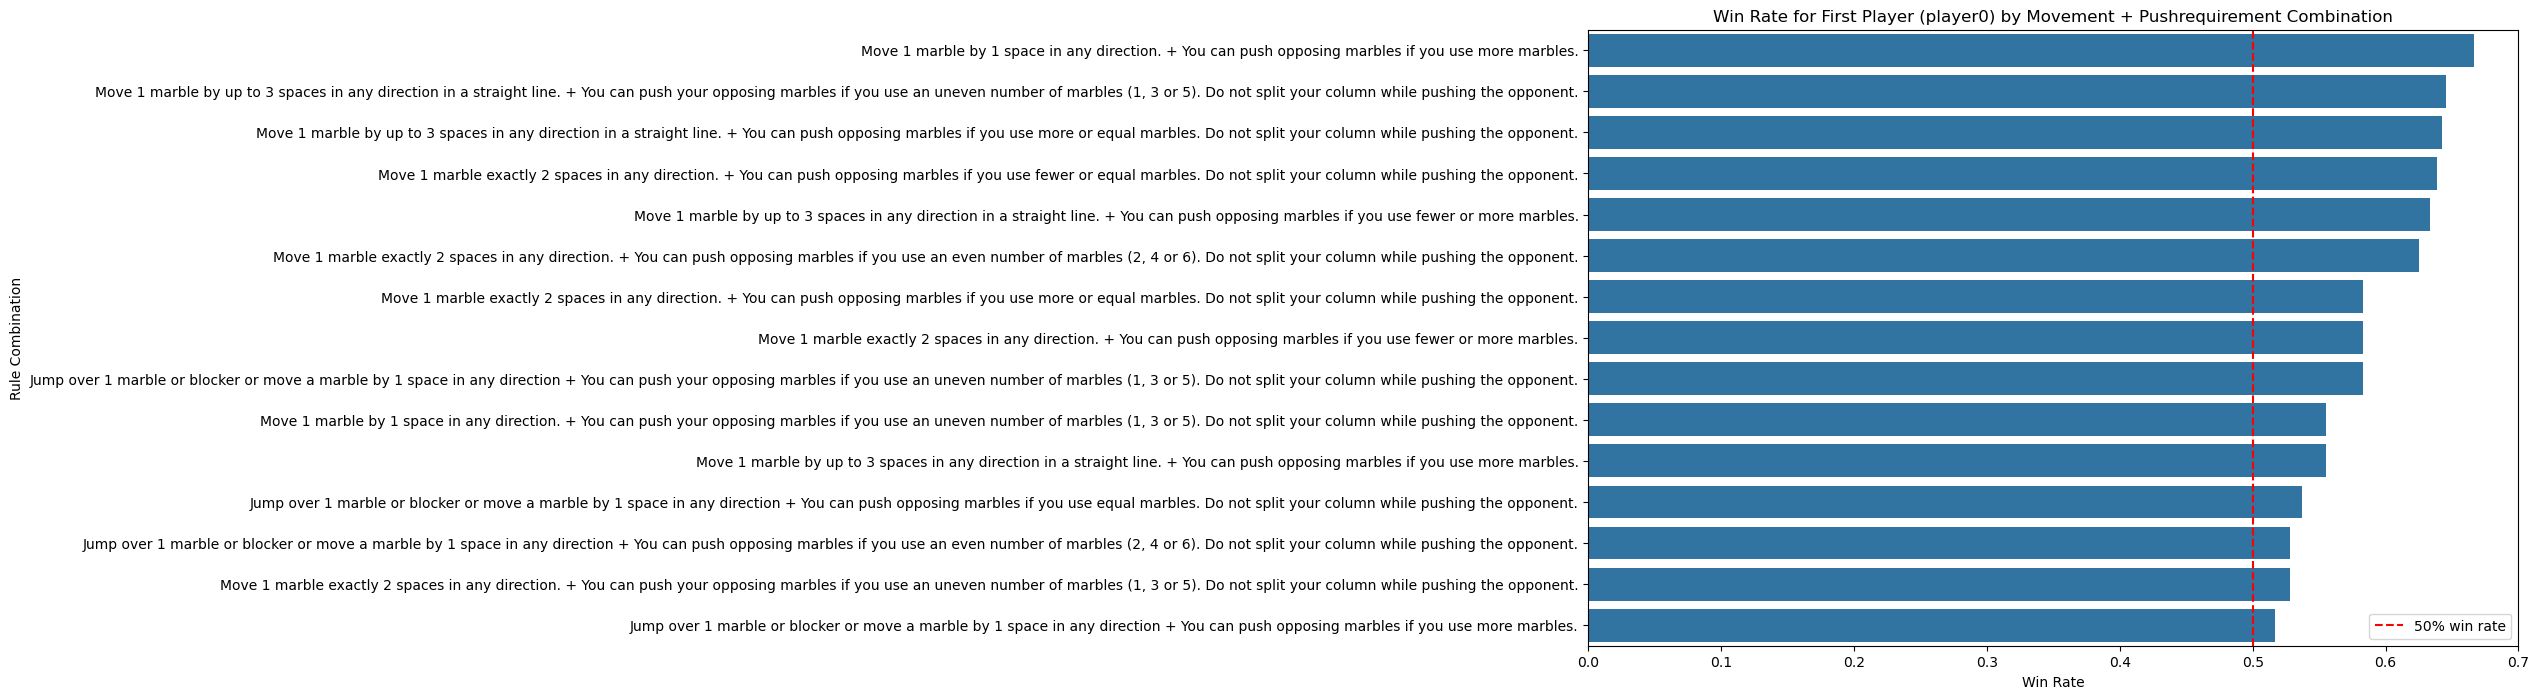


--- Analysis for MOVEMENT vs VICTORY rule combinations ---
Win rates for the first player (player0) by movement + victory combination:
                                            rule_pair  player0_win_rate  count
12  Move 1 marble exactly 2 spaces in any directio...          0.621212     66
8   Move 1 marble by up to 3 spaces in any directi...          0.611111     72
9   Move 1 marble by up to 3 spaces in any directi...          0.569444     72
10  Move 1 marble by up to 3 spaces in any directi...          0.562500     48
14  Move 1 marble exactly 2 spaces in any directio...          0.545455     66
2   Jump over 1 marble or blocker or move a marble...          0.523810     84
0   Jump over 1 marble or blocker or move a marble...          0.500000     66
1   Jump over 1 marble or blocker or move a marble...          0.500000     48
5   Move 1 marble by 1 space in any direction. + O...          0.500000     36
13  Move 1 marble exactly 2 spaces in any directio...          0.500000   

C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


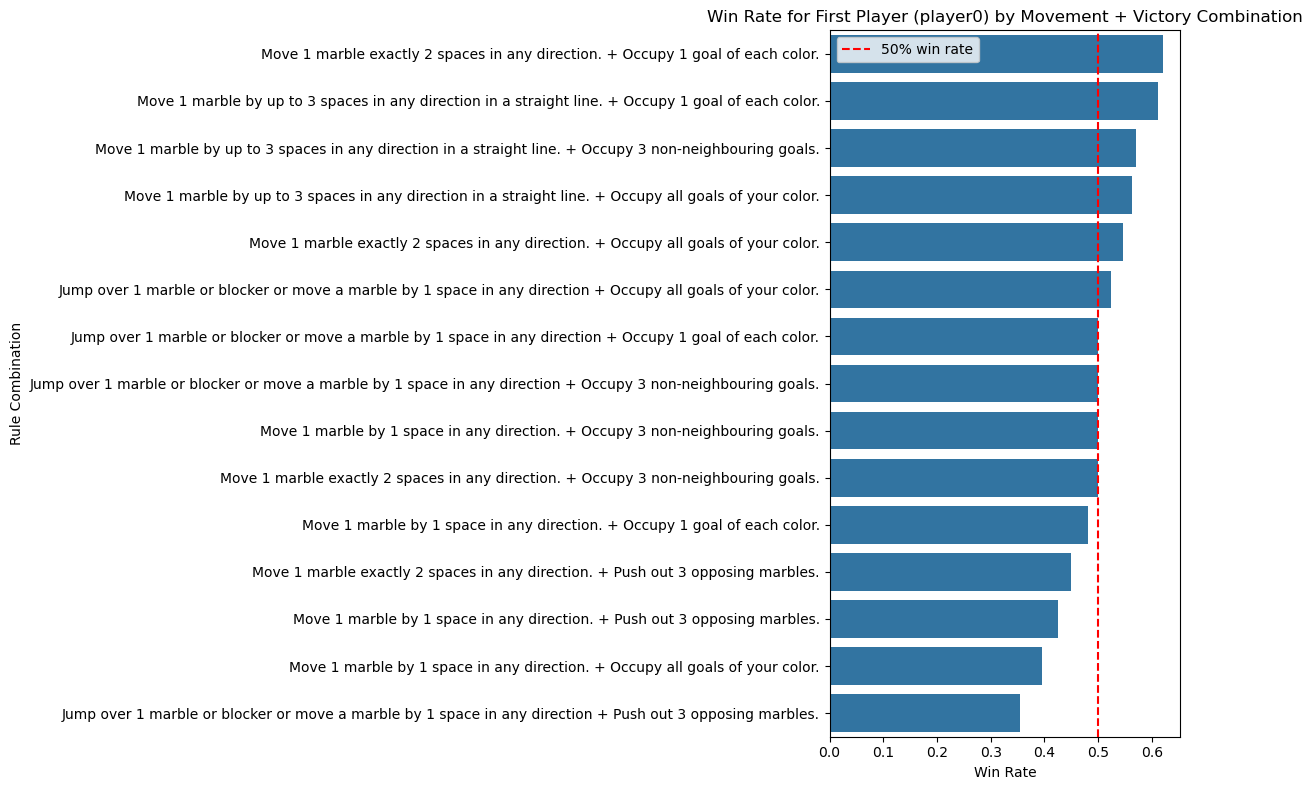


--- Analysis for PUSH vs PUSHOUT rule combinations ---
Win rates for the first player (player0) by push + pushout combination:
                                           rule_pair  player0_win_rate  count
2  Push a column of marbles by 1 space in any dir...          0.512121    330
0  Push a column of marbles by 1 space in any dir...          0.500000    342
1  Push a column of marbles by 1 space in any dir...          0.487654    324


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


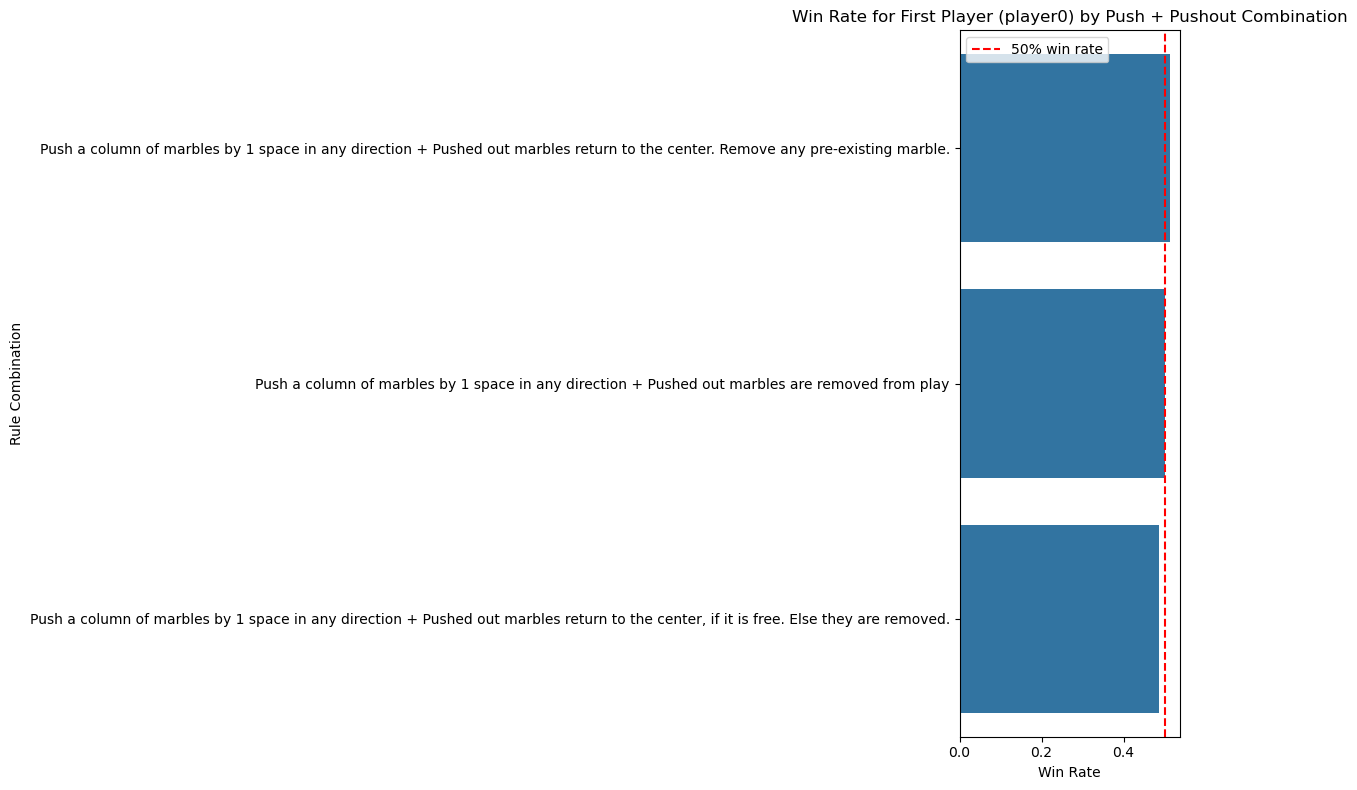


--- Analysis for PUSH vs PUSHREQUIREMENT rule combinations ---
Win rates for the first player (player0) by push + pushrequirement combination:
                                           rule_pair  player0_win_rate  count
6  Push a column of marbles by 1 space in any dir...          0.587719    114
0  Push a column of marbles by 1 space in any dir...          0.530864    162
5  Push a column of marbles by 1 space in any dir...          0.520000    150
3  Push a column of marbles by 1 space in any dir...          0.500000    120
4  Push a column of marbles by 1 space in any dir...          0.493827    162
2  Push a column of marbles by 1 space in any dir...          0.448718    156
1  Push a column of marbles by 1 space in any dir...          0.431818    132


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:92: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


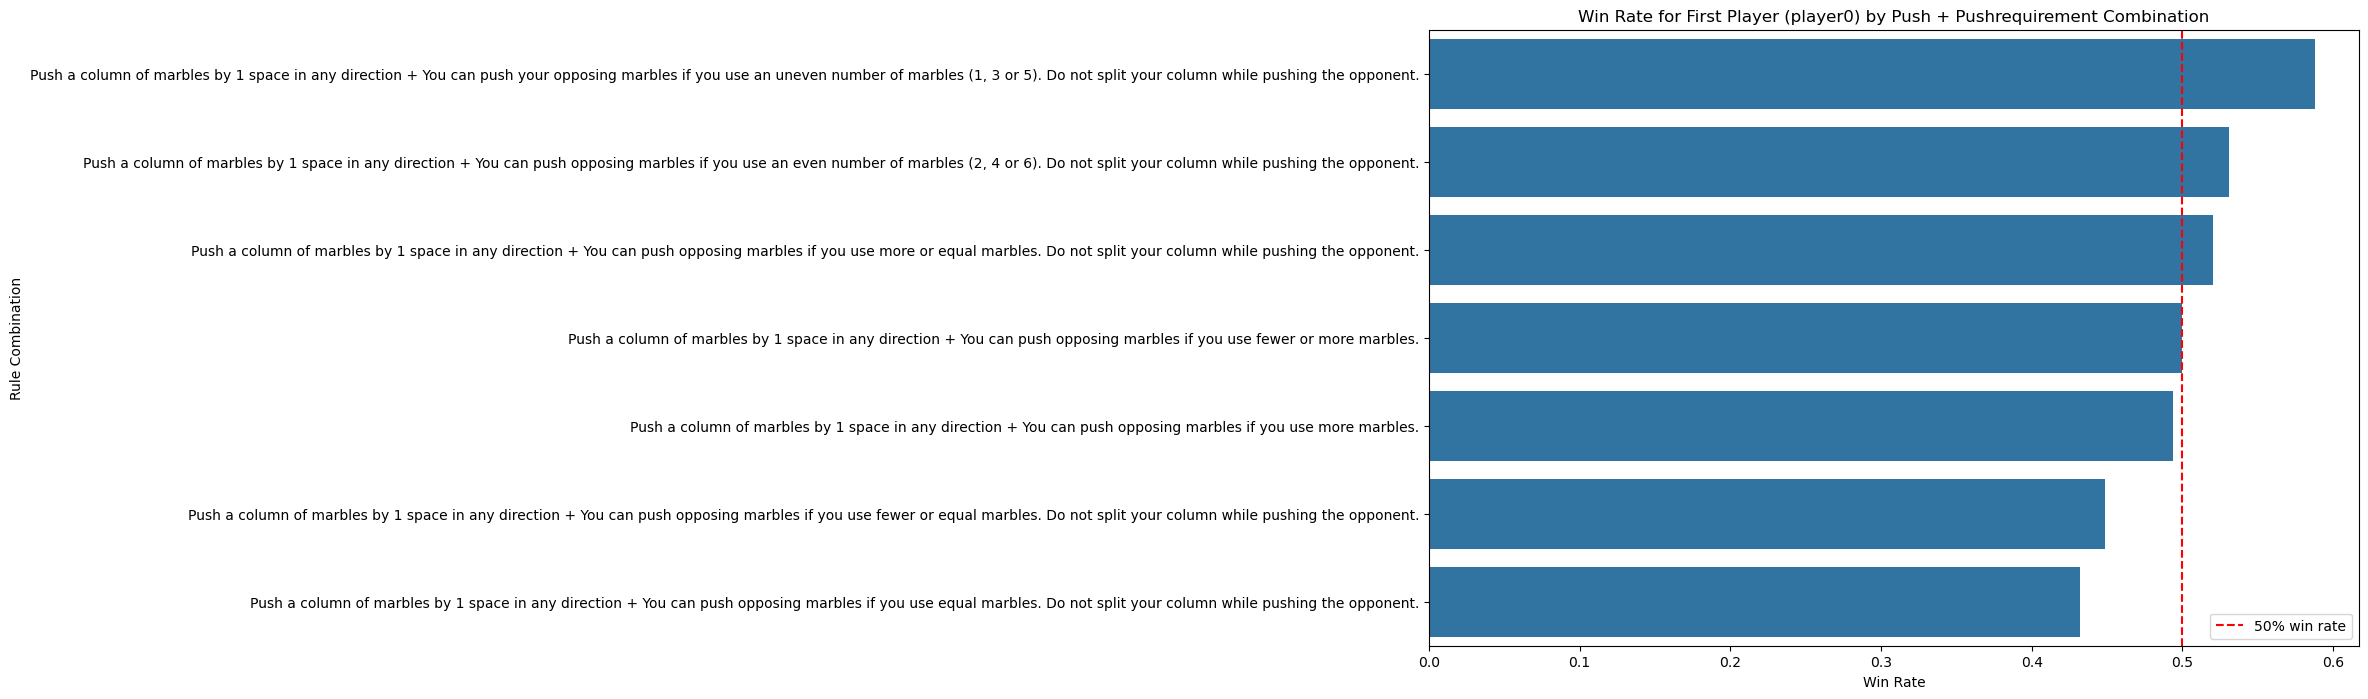


--- Analysis for PUSH vs VICTORY rule combinations ---
Win rates for the first player (player0) by push + victory combination:
                                           rule_pair  player0_win_rate  count
0  Push a column of marbles by 1 space in any dir...          0.545752    306
1  Push a column of marbles by 1 space in any dir...          0.521930    228
2  Push a column of marbles by 1 space in any dir...          0.512195    246
3  Push a column of marbles by 1 space in any dir...          0.398148    216


C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


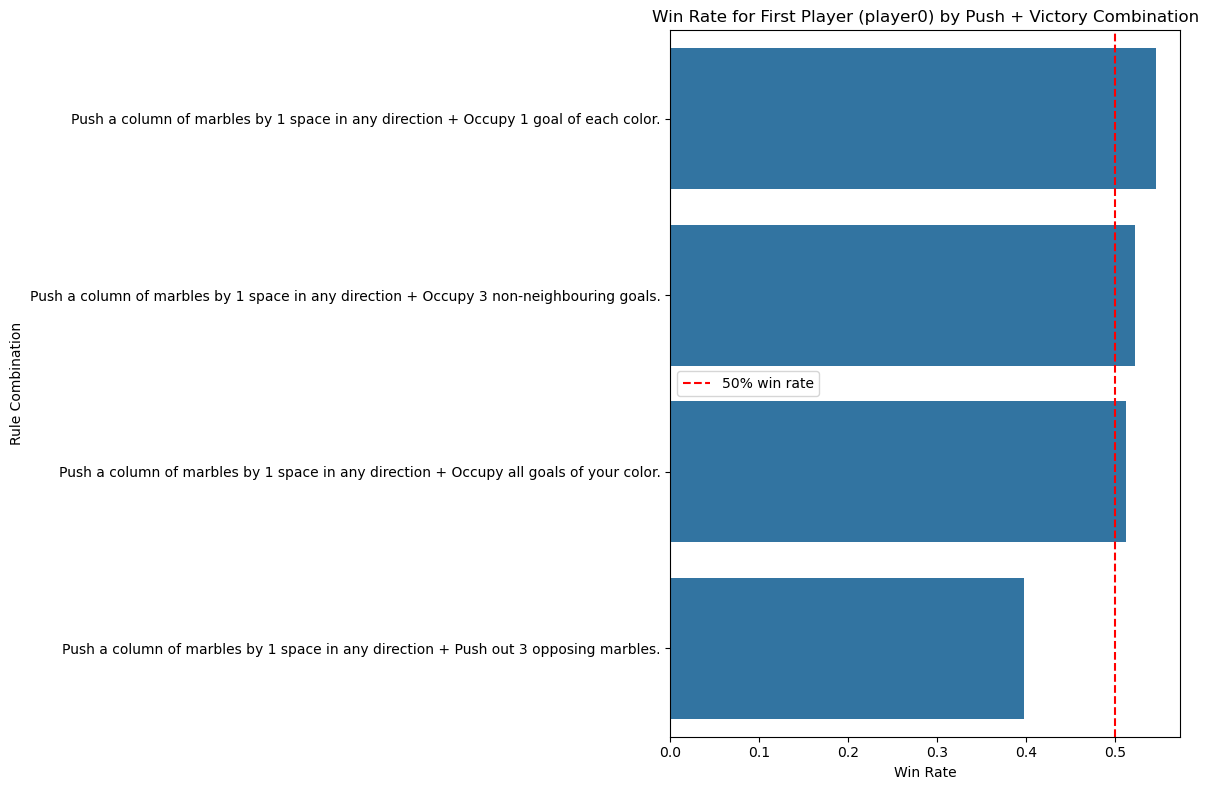


--- Analysis for PUSHOUT vs PUSHREQUIREMENT rule combinations ---
Win rates for the first player (player0) by pushout + pushrequirement combination:
                                            rule_pair  player0_win_rate  count
15  Pushed out marbles return to the center. Remov...          0.666667     30
3   Pushed out marbles are removed from play + You...          0.625000     24
13  Pushed out marbles return to the center, if it...          0.625000     24
20  Pushed out marbles return to the center. Remov...          0.600000     60
12  Pushed out marbles return to the center, if it...          0.583333     24
7   Pushed out marbles return to the center, if it...          0.550000     60
0   Pushed out marbles are removed from play + You...          0.550000     60
10  Pushed out marbles return to the center, if it...          0.541667     48
6   Pushed out marbles are removed from play + You...          0.533333     30
4   Pushed out marbles are removed from play + You...       

C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:92: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


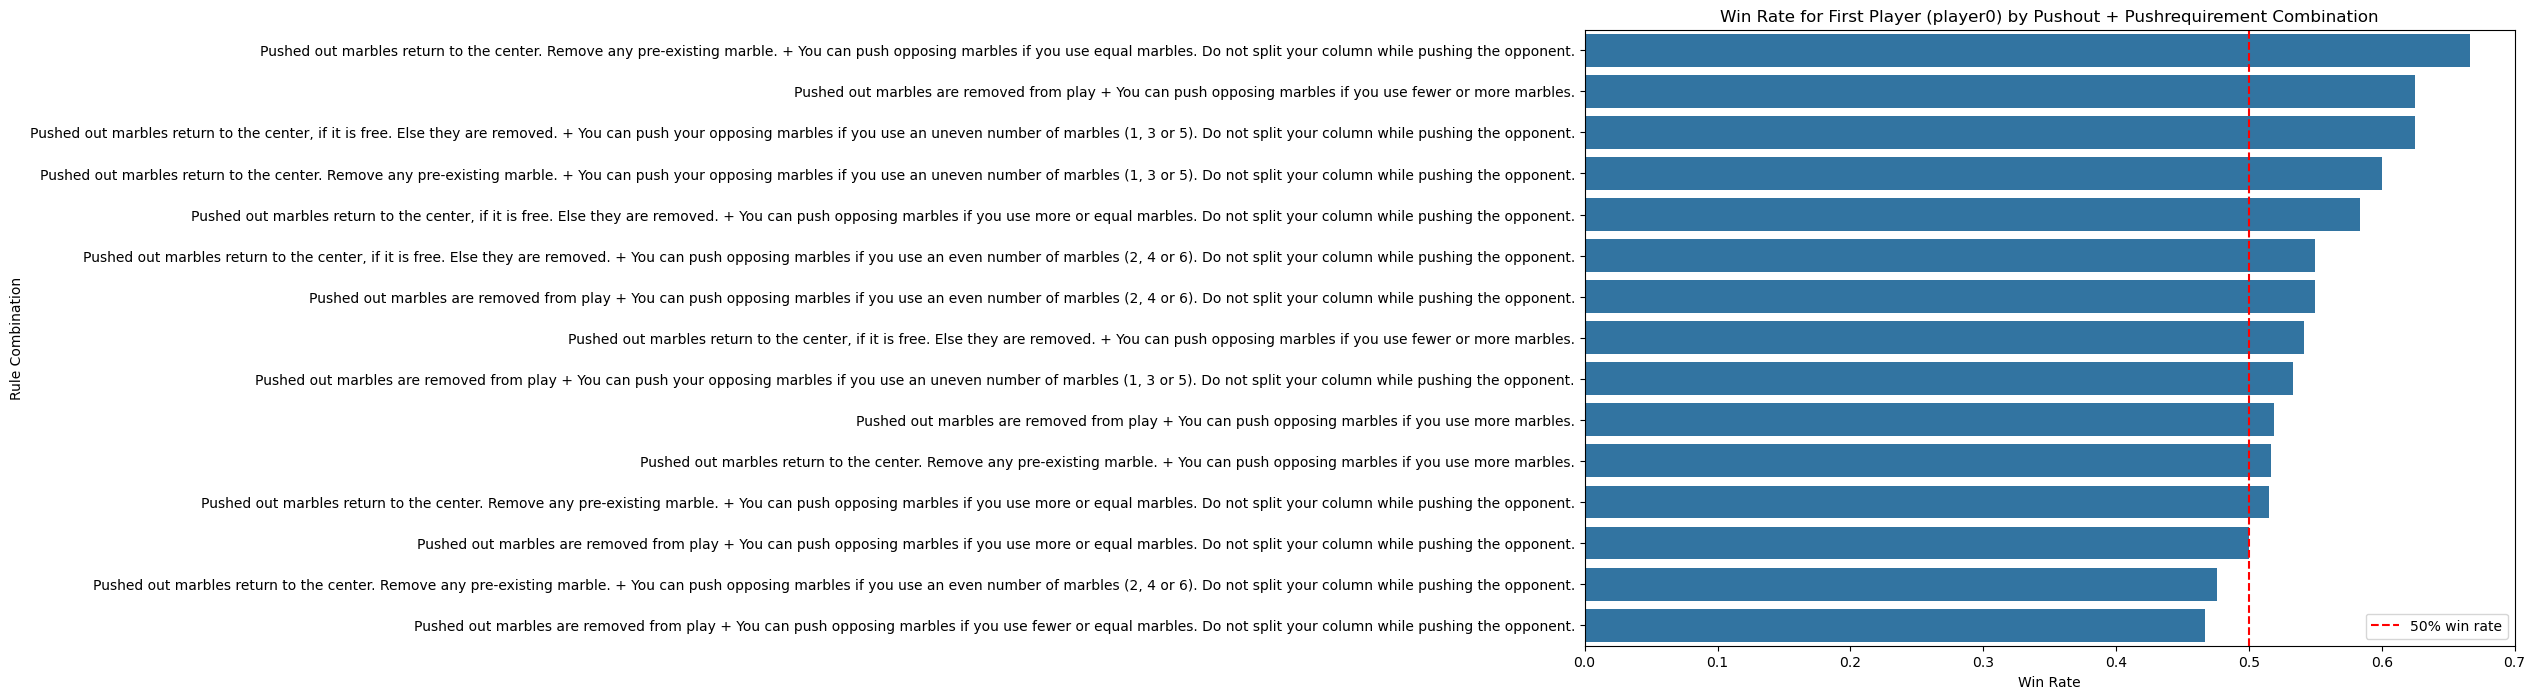


--- Analysis for PUSHOUT vs VICTORY rule combinations ---
Win rates for the first player (player0) by pushout + victory combination:
                                            rule_pair  player0_win_rate  count
5   Pushed out marbles return to the center, if it...          0.666667     54
10  Pushed out marbles return to the center. Remov...          0.575758     66
8   Pushed out marbles return to the center. Remov...          0.558333    120
0   Pushed out marbles are removed from play + Occ...          0.549020    102
2   Pushed out marbles are removed from play + Occ...          0.535714     84
1   Pushed out marbles are removed from play + Occ...          0.527778     72
4   Pushed out marbles return to the center, if it...          0.523810     84
11  Pushed out marbles return to the center. Remov...          0.452381     42
6   Pushed out marbles return to the center, if it...          0.447917     96
9   Pushed out marbles return to the center. Remov...          0.441176    1

C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(


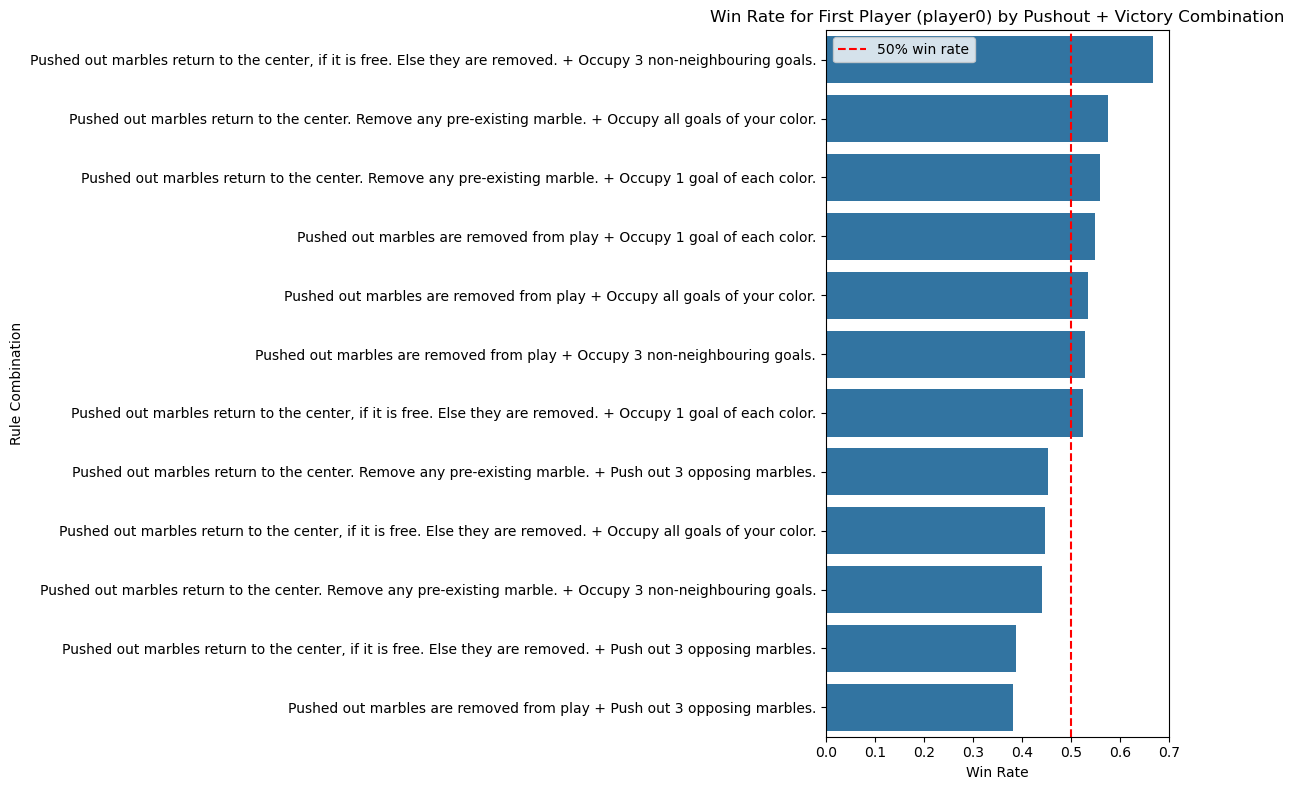


--- Analysis for PUSHREQUIREMENT vs VICTORY rule combinations ---
Win rates for the first player (player0) by pushrequirement + victory combination:
                                            rule_pair  player0_win_rate  count
24  You can push your opposing marbles if you use ...          0.694444     36
16  You can push opposing marbles if you use more ...          0.638889     36
2   You can push opposing marbles if you use an ev...          0.619048     42
25  You can push your opposing marbles if you use ...          0.619048     42
14  You can push opposing marbles if you use fewer...          0.600000     30
23  You can push opposing marbles if you use more ...          0.583333     24
4   You can push opposing marbles if you use equal...          0.571429     42
9   You can push opposing marbles if you use fewer...          0.555556     36
21  You can push opposing marbles if you use more ...          0.555556     18
8   You can push opposing marbles if you use fewer...       

C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rates = dataframe.groupby('rule_pair').apply(
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\3093219545.py:92: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


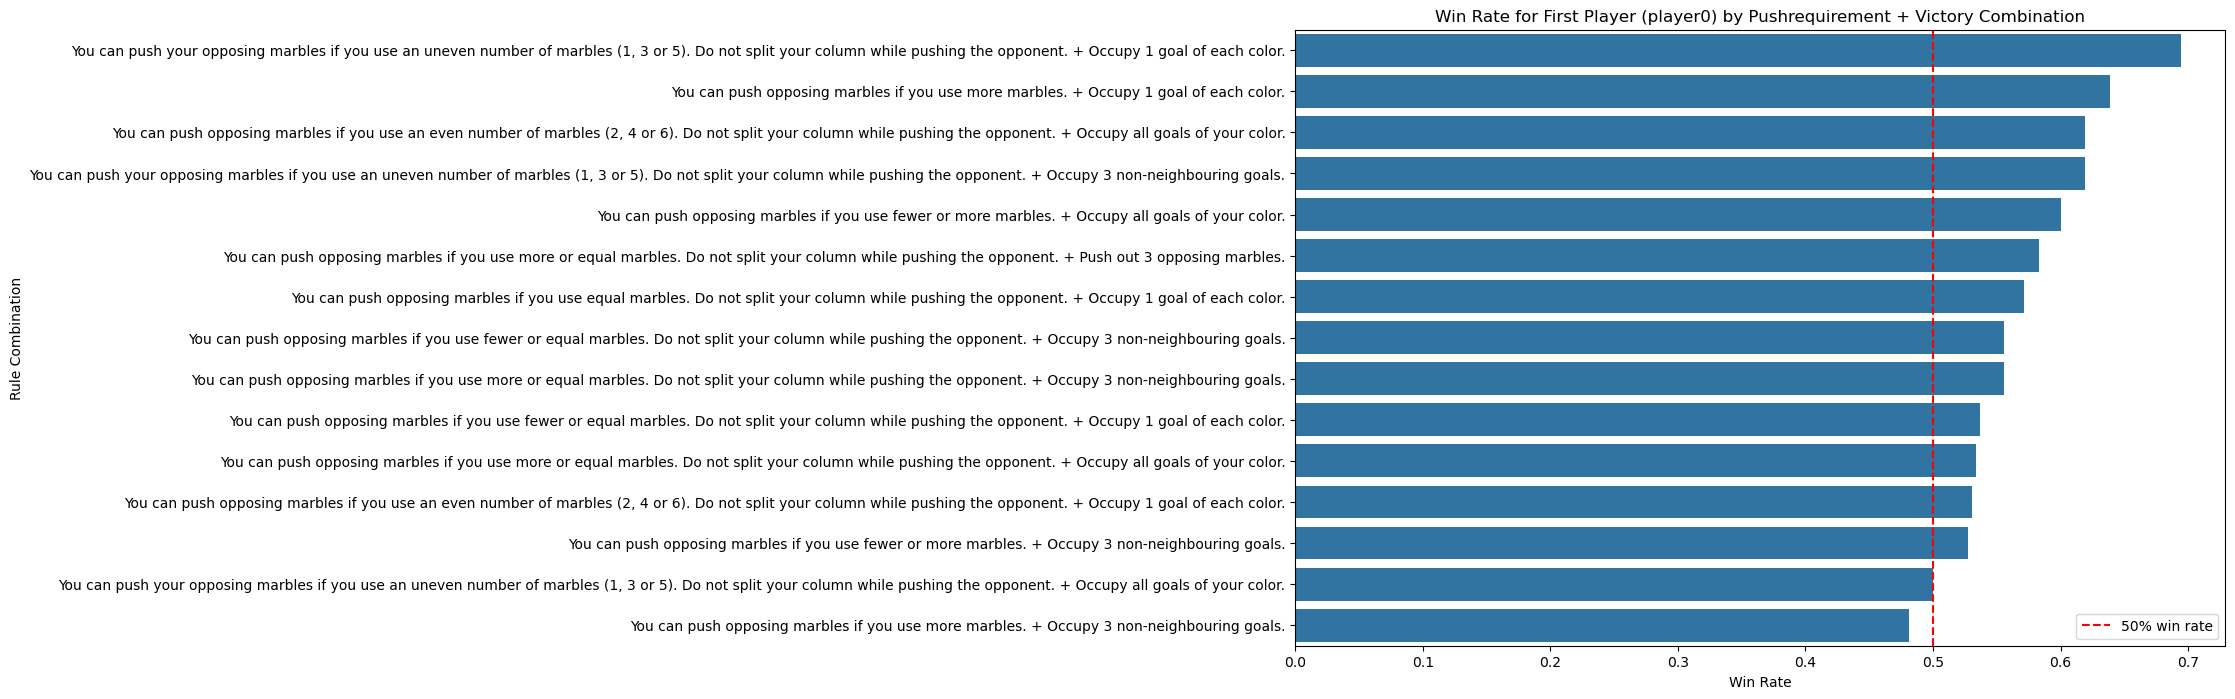

TypeError: Image data of dtype object cannot be converted to float

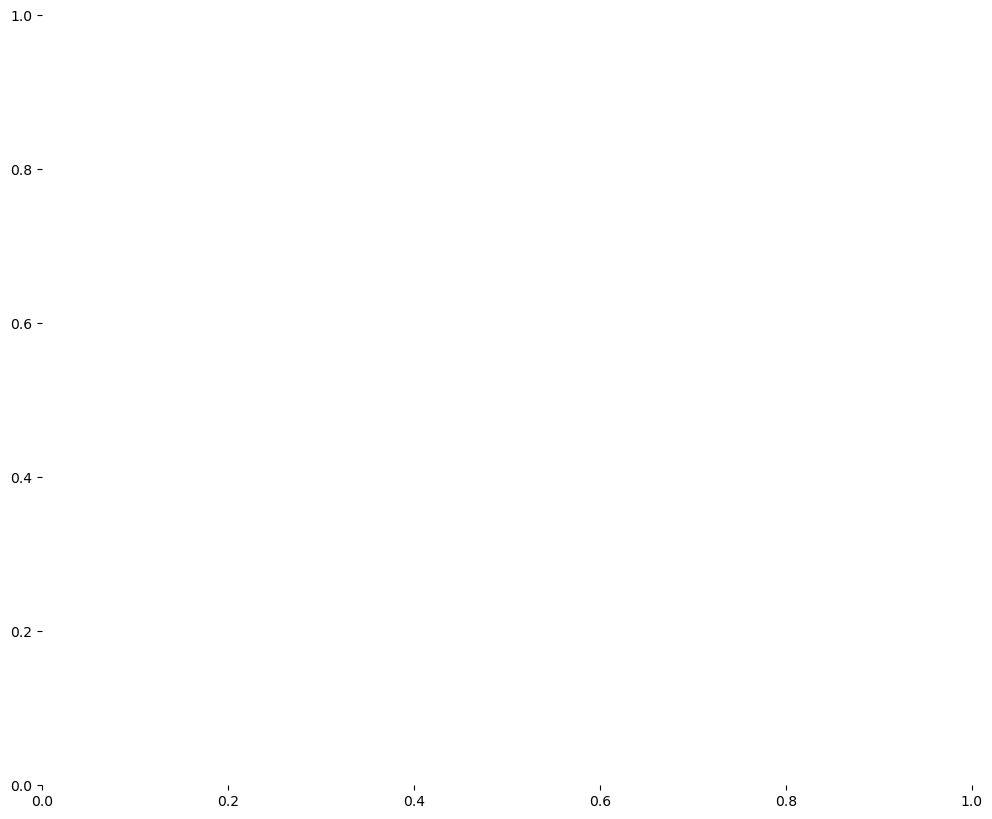

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the rule information from your dataframe
# Create a rule combination identifier for each game
dataframe['rule_setup'] = dataframe['RuleCardsUsed(Rule-Setup)']
dataframe['rule_movement'] = dataframe['RuleCardsUsed(Rule-Movement)']
dataframe['rule_push'] = dataframe['RuleCardsUsed(Rule-Push)']
dataframe['rule_pushout'] = dataframe['RuleCardsUsed(Rule-PushOut)']
dataframe['rule_pushrequirement'] = dataframe['RuleCardsUsed(Rule-PushRequirement)']
dataframe['rule_victory'] = dataframe['RuleCardsUsed(Rule-Victory)']

# Create columns for each rule type combination
rule_types = ['setup', 'movement', 'push', 'pushout', 'pushrequirement', 'victory']

# Analyze each rule type separately
for rule_type in rule_types:
    print(f"\n--- Analysis for {rule_type.upper()} rules ---")
    
    # Calculate win rate for player0 (first player) for each rule
    win_rates = dataframe.groupby(f'rule_{rule_type}').apply(
        lambda x: (x['Winner(PlayerIdx)'] == 0).mean()  # Calculate percentage where winner is player0
    ).reset_index(name='player0_win_rate')
    
    # Sort by win rate for better visualization
    win_rates = win_rates.sort_values('player0_win_rate', ascending=False)
    
    # Display the win rates
    print(f"Win rates for the first player (player0) by {rule_type} rule:")
    print(win_rates)
    
    # Create a bar chart to visualize the win rates
    plt.figure(figsize=(10, 6))
    sns.barplot(x=f'rule_{rule_type}', y='player0_win_rate', data=win_rates)
    plt.title(f'Win Rate for First Player (player0) by {rule_type.capitalize()} Rule')
    plt.xlabel(f'{rule_type.capitalize()} Rule')
    plt.ylabel('Win Rate')
    plt.axhline(y=0.5, color='red', linestyle='--', label='50% win rate')
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Now analyze rule pairs (combinations of two different rule types)
print("\n--- Analysis for RULE PAIRS ---")

# Create a list of all possible pairs of rule types
rule_pairs = []
for i in range(len(rule_types)):
    for j in range(i+1, len(rule_types)):
        rule_pairs.append((rule_types[i], rule_types[j]))

# Analyze each rule pair
for rule1_type, rule2_type in rule_pairs:
    print(f"\n--- Analysis for {rule1_type.upper()} vs {rule2_type.upper()} rule combinations ---")
    
    # Group by both rule types
    dataframe['rule_pair'] = dataframe[f'rule_{rule1_type}'] + ' + ' + dataframe[f'rule_{rule2_type}']
    
    # Calculate win rate for player0 (first player) for each rule pair
    win_rates = dataframe.groupby('rule_pair').apply(
        lambda x: (x['Winner(PlayerIdx)'] == 0).mean()
    ).reset_index(name='player0_win_rate')
    
    # Only keep pairs with sufficient data (optional)
    pair_counts = dataframe.groupby('rule_pair').size().reset_index(name='count')
    win_rates = win_rates.merge(pair_counts, on='rule_pair')
    win_rates = win_rates[win_rates['count'] >= 10]  # Only include pairs with at least 10 games
    
    if len(win_rates) == 0:
        print(f"Not enough data for {rule1_type} vs {rule2_type} combinations")
        continue
    
    # Sort by win rate for better visualization
    win_rates = win_rates.sort_values('player0_win_rate', ascending=False)
    
    # Display the win rates
    print(f"Win rates for the first player (player0) by {rule1_type} + {rule2_type} combination:")
    print(win_rates[['rule_pair', 'player0_win_rate', 'count']])
    
    # Create a bar chart for the top 15 combinations (to avoid overcrowding)
    plt.figure(figsize=(12, 8))
    top_pairs = win_rates.head(15)
    sns.barplot(x='player0_win_rate', y='rule_pair', data=top_pairs)
    plt.title(f'Win Rate for First Player (player0) by {rule1_type.capitalize()} + {rule2_type.capitalize()} Combination')
    plt.xlabel('Win Rate')
    plt.ylabel('Rule Combination')
    plt.axvline(x=0.5, color='red', linestyle='--', label='50% win rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Create a heatmap for victory rules (usually the most important for win conditions)
victory_rules = dataframe['rule_victory'].unique()
setup_rules = dataframe['rule_setup'].unique()

# Create a heatmap for victory vs setup rules
heatmap_data = pd.DataFrame(index=victory_rules, columns=setup_rules)

for victory in victory_rules:
    for setup in setup_rules:
        # Filter data for this combination
        filtered = dataframe[(dataframe['rule_victory'] == victory) & (dataframe['rule_setup'] == setup)]
        if len(filtered) >= 10:  # Only include if we have enough data
            heatmap_data.loc[victory, setup] = (filtered['Winner(PlayerIdx)'] == 0).mean()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", vmin=0, vmax=1, center=0.5)
plt.title('First Player Win Rate by Victory Rule vs Setup Rule')
plt.tight_layout()
plt.show()

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the output path
output_path = r"C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment"

# Extract the rule information from your dataframe (excluding setup)
rule_types = ['movement', 'push', 'pushout', 'pushrequirement', 'victory']
rule_columns = {
    'movement': 'RuleCardsUsed(Rule-Movement)',
    'push': 'RuleCardsUsed(Rule-Push)',
    'pushout': 'RuleCardsUsed(Rule-PushOut)',
    'pushrequirement': 'RuleCardsUsed(Rule-PushRequirement)',
    'victory': 'RuleCardsUsed(Rule-Victory)'
}

# Create a new dataframe to store all rule combinations and their win rates
all_combinations = []

# First, analyze each rule type individually
for rule_type, column in rule_columns.items():
    # Group by the rule and calculate win rate
    grouped = dataframe.groupby(column).agg(
        player0_wins=pd.NamedAgg(column='Winner(PlayerIdx)', aggfunc=lambda x: (x == 0).sum()),
        total_games=pd.NamedAgg(column='Winner(PlayerIdx)', aggfunc='count')
    )
    grouped['win_rate'] = grouped['player0_wins'] / grouped['total_games']
    
    # Add to our collection
    for rule_value, row in grouped.iterrows():
        all_combinations.append({
            'rule_type': rule_type,
            'rule_value': rule_value,
            'combination': f"{rule_type}: {rule_value}",
            'player0_win_rate': row['win_rate'],
            'total_games': row['total_games'],
            'player0_wins': row['player0_wins']
        })
    
    # Create and save individual rule type plots
    plt.figure(figsize=(12, 6))
    plot_data = grouped.reset_index().sort_values('win_rate', ascending=False)
    sns.barplot(x='win_rate', y=column, data=plot_data)
    plt.title(f'Win Rate for First Player (player0) by {rule_type.capitalize()} Rule')
    plt.xlabel('Win Rate')
    plt.ylabel(f'{rule_type.capitalize()} Rule')
    plt.axvline(x=0.5, color='red', linestyle='--', label='50% win rate')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, f'winrate_{rule_type}_rules.png'))
    plt.close()

# Now analyze all possible pairs of rule types
for i, rule1_type in enumerate(rule_types):
    for j, rule2_type in enumerate(rule_types):
        if i >= j:  # Skip duplicates and same-type pairs
            continue
            
        # Get the column names
        col1 = rule_columns[rule1_type]
        col2 = rule_columns[rule2_type]
        
        # Group by both rules
        grouped = dataframe.groupby([col1, col2]).agg(
            player0_wins=pd.NamedAgg(column='Winner(PlayerIdx)', aggfunc=lambda x: (x == 0).sum()),
            total_games=pd.NamedAgg(column='Winner(PlayerIdx)', aggfunc='count')
        )
        
        # Only keep combinations with sufficient data
        grouped = grouped[grouped['total_games'] >= 10]
        
        if len(grouped) == 0:
            continue
            
        grouped['win_rate'] = grouped['player0_wins'] / grouped['total_games']
        
        # Add to our collection
        for (rule1_value, rule2_value), row in grouped.iterrows():
            combination = f"{rule1_type}: {rule1_value} + {rule2_type}: {rule2_value}"
            all_combinations.append({
                'rule_type': f"{rule1_type}_{rule2_type}",
                'rule_value': f"{rule1_value}_{rule2_value}",
                'combination': combination,
                'player0_win_rate': row['win_rate'],
                'total_games': row['total_games'],
                'player0_wins': row['player0_wins']
            })
        
        # Create and save pair plots for top combinations
        plot_data = grouped.reset_index().sort_values('win_rate', ascending=False)
        if len(plot_data) > 15:
            plot_data = plot_data.head(15)  # Limit to top 15 for readability
            
        plt.figure(figsize=(14, 10))
        plot_data['combination'] = plot_data.apply(lambda x: f"{x[col1]} + {x[col2]}", axis=1)
        sns.barplot(x='win_rate', y='combination', data=plot_data)
        plt.title(f'Win Rate for First Player by {rule1_type.capitalize()} + {rule2_type.capitalize()} Combination')
        plt.xlabel('Win Rate')
        plt.ylabel('Rule Combination')
        plt.axvline(x=0.5, color='red', linestyle='--', label='50% win rate')
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_path, f'winrate_{rule1_type}_{rule2_type}_combination.png'))
        plt.close()

# Create a comprehensive dataframe with all combinations
all_combinations_df = pd.DataFrame(all_combinations)
all_combinations_df = all_combinations_df.sort_values('player0_win_rate', ascending=False)

# Save the comprehensive dataframe to CSV
all_combinations_df.to_csv(os.path.join(output_path, 'rule_combinations_winrates.csv'), index=False)

# Create a summary plot of the top and bottom 15 combinations
plt.figure(figsize=(14, 12))

# Top 15
plt.subplot(2, 1, 1)
top_15 = all_combinations_df.head(15)
sns.barplot(x='player0_win_rate', y='combination', data=top_15)
plt.title('Top 15 Rule Combinations by First Player Win Rate')
plt.xlabel('Win Rate')
plt.ylabel('Rule Combination')
plt.axvline(x=0.5, color='red', linestyle='--', label='50% win rate')
plt.legend()

# Bottom 15
plt.subplot(2, 1, 2)
bottom_15 = all_combinations_df.tail(15).sort_values('player0_win_rate')
sns.barplot(x='player0_win_rate', y='combination', data=bottom_15)
plt.title('Bottom 15 Rule Combinations by First Player Win Rate')
plt.xlabel('Win Rate')
plt.ylabel('Rule Combination')
plt.axvline(x=0.5, color='red', linestyle='--', label='50% win rate')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'winrate_top_bottom_combinations.png'))
plt.close()

# Create a heatmap for victory vs movement rules (often important)
victory_rules = dataframe[rule_columns['victory']].unique()
movement_rules = dataframe[rule_columns['movement']].unique()

# Create a heatmap for victory vs movement rules
heatmap_data = pd.DataFrame(index=victory_rules, columns=movement_rules)

# Create a heatmap for victory vs movement rules
heatmap_data = pd.DataFrame(index=victory_rules, columns=movement_rules)

for victory in victory_rules:
    for movement in movement_rules:
        # Filter data for this combination
        filtered = dataframe[(dataframe[rule_columns['victory']] == victory) & 
                           (dataframe[rule_columns['movement']] == movement)]
        if len(filtered) >= 10:  # Only include if we have enough data
            heatmap_data.loc[victory, movement] = (filtered['Winner(PlayerIdx)'] == 0).mean()

# Plot the heatmap
plt.figure(figsize=(14, 10))
# Convert heatmap_data to numeric values, coercing errors to NaN
heatmap_data = heatmap_data.apply(pd.to_numeric, errors='coerce')
# Now create the heatmap with the numeric data
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", vmin=0, vmax=1, center=0.5, fmt='.3f')
plt.title(f'First Player Win Rate by {rule1_type.capitalize()} Rule vs {rule2_type.capitalize()} Rule')
plt.tight_layout()
plt.savefig(os.path.join(output_path, f'winrate_heatmap_{rule1_type}_{rule2_type}.png'))
plt.close()

# Create heatmaps for all pairs of rule types
for i, rule1_type in enumerate(rule_types):
    for j, rule2_type in enumerate(rule_types):
        if i >= j:  # Skip duplicates and same-type pairs
            continue
            
        # Get the column names
        col1 = rule_columns[rule1_type]
        col2 = rule_columns[rule2_type]
        
        # Get unique values for each rule type
        rule1_values = dataframe[col1].unique()
        rule2_values = dataframe[col2].unique()
        
        # Create a heatmap for this rule pair
        heatmap_data = pd.DataFrame(index=rule1_values, columns=rule2_values)
        
        for rule1_value in rule1_values:
            for rule2_value in rule2_values:
                # Filter data for this combination
                filtered = dataframe[(dataframe[col1] == rule1_value) & 
                                   (dataframe[col2] == rule2_value)]
                if len(filtered) >= 10:  # Only include if we have enough data
                    heatmap_data.loc[rule1_value, rule2_value] = (filtered['Winner(PlayerIdx)'] == 0).mean()
        
        # Remove rows and columns that are all NaN
        heatmap_data = heatmap_data.dropna(how='all').dropna(axis=1, how='all')
        
        if heatmap_data.empty:
            continue
            
        # Before creating the heatmap, ensure all data is numeric
        heatmap_data = heatmap_data.dropna(how='all').dropna(axis=1, how='all')
        
        if heatmap_data.empty:
            continue
            
        # Convert all data to numeric, coercing errors to NaN
        heatmap_data = heatmap_data.apply(pd.to_numeric, errors='coerce')
        
        # Drop any remaining NaN values after conversion
        heatmap_data = heatmap_data.dropna(how='all').dropna(axis=1, how='all')
        
        if heatmap_data.empty:
            continue
            
        # Plot the heatmap
        plt.figure(figsize=(14, 10))
        sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", vmin=0, vmax=1, center=0.5, fmt='.3f')
        plt.title(f'First Player Win Rate by {rule1_type.capitalize()} Rule vs {rule2_type.capitalize()} Rule')
        plt.tight_layout()
        plt.savefig(os.path.join(output_path, f'winrate_heatmap_{rule1_type}_{rule2_type}.png'))
        plt.close()
# Create a summary statistics table
summary_stats = all_combinations_df.groupby('rule_type').agg(
    avg_win_rate=pd.NamedAgg(column='player0_win_rate', aggfunc='mean'),
    min_win_rate=pd.NamedAgg(column='player0_win_rate', aggfunc='min'),
    max_win_rate=pd.NamedAgg(column='player0_win_rate', aggfunc='max'),
    std_win_rate=pd.NamedAgg(column='player0_win_rate', aggfunc='std'),
    total_combinations=pd.NamedAgg(column='player0_win_rate', aggfunc='count')
).reset_index()

# Save summary statistics
summary_stats.to_csv(os.path.join(output_path, 'rule_winrate_summary_stats.csv'), index=False)

# Create a summary plot
plt.figure(figsize=(12, 8))
sns.barplot(x='rule_type', y='avg_win_rate', data=summary_stats)
plt.errorbar(
    x=range(len(summary_stats)),
    y=summary_stats['avg_win_rate'],
    yerr=summary_stats['std_win_rate'],
    fmt='none',
    color='black',
    capsize=5
)
plt.axhline(y=0.5, color='red', linestyle='--', label='50% win rate')
plt.title('Average First Player Win Rate by Rule Type')
plt.xlabel('Rule Type')
plt.ylabel('Average Win Rate')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'winrate_summary_by_rule_type.png'))
plt.close()

print(f"Analysis complete. All results saved to {output_path}")

C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\163692859.py:105: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\163692859.py:105: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\163692859.py:105: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\163692859.py:139: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\163692859.py:222: UserWarning: Tight layout not applied. The bottom an

Analysis complete. All results saved to C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the output path
output_path = r"C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\WinrateAnalysis"

# Create the directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Load the previously created CSV file
all_combinations_df = pd.read_csv(r"C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\WinrateAnalysis\rule_combinations_winrates.csv")

# Calculate how polarized each combination is (distance from 0.5)
all_combinations_df['polarization'] = abs(all_combinations_df['player0_win_rate'] - 0.5)

# Sort by polarization (most polarized first)
polarized_df = all_combinations_df.sort_values('polarization', ascending=False)

# Save the polarized dataframe
polarized_df.to_csv(os.path.join(output_path, 'rule_combinations_by_polarization.csv'), index=False)

# Create a visualization of the most polarized combinations
plt.figure(figsize=(14, 10))
top_polarized = polarized_df.head(20)  # Top 20 most polarized combinations

# Create a diverging color palette based on whether win rate favors player 0 or player 1
colors = ['red' if x > 0.5 else 'blue' for x in top_polarized['player0_win_rate']]

# Create the bar chart
bars = plt.barh(y=top_polarized['combination'], 
                width=top_polarized['player0_win_rate'], 
                color=colors)

# Add a vertical line at 0.5
plt.axvline(x=0.5, color='black', linestyle='--', label='Balanced (50%)')

# Add labels showing the actual win rate and sample size
for i, bar in enumerate(bars):
    win_rate = top_polarized.iloc[i]['player0_win_rate']
    games = top_polarized.iloc[i]['total_games']
    plt.text(
        max(win_rate + 0.02, 0.52) if win_rate > 0.5 else min(win_rate - 0.02, 0.48),
        bar.get_y() + bar.get_height()/2,
        f"{win_rate:.3f} ({games} games)",
        va='center',
        ha='left' if win_rate > 0.5 else 'right',
        fontweight='bold'
    )

plt.title('Top 20 Most Polarized Rule Combinations by First Player Win Rate', fontsize=16)
plt.xlabel('Win Rate for First Player (player0)', fontsize=12)
plt.ylabel('Rule Combination', fontsize=12)
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'top_polarized_combinations.png'))
plt.close()

# Create a scatter plot of all combinations showing polarization vs sample size
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    x=all_combinations_df['total_games'],
    y=all_combinations_df['polarization'],
    c=abs(all_combinations_df['player0_win_rate'] - 0.5),
    cmap='viridis',
    alpha=0.7,
    s=100,
    edgecolors='black'
)

# Add a horizontal line at 0 (perfectly balanced)
plt.axhline(y=0, color='red', linestyle='--', label='Perfectly Balanced')

# Add labels for the most polarized points
for i, row in polarized_df.head(10).iterrows():
    plt.annotate(
        row['combination'],
        xy=(row['total_games'], row['polarization']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2')
    )

plt.title('Polarization vs. Sample Size for All Rule Combinations', fontsize=16)
plt.xlabel('Number of Games', fontsize=12)
plt.ylabel('Polarization (Distance from 50% Win Rate)', fontsize=12)
plt.xscale('log')  # Log scale for better visualization if there's a wide range of sample sizes
plt.colorbar(scatter, label='Polarization Intensity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'polarization_vs_sample_size.png'))
plt.close()

# Create a histogram of win rates to see the overall distribution
plt.figure(figsize=(12, 8))
sns.histplot(all_combinations_df['player0_win_rate'], bins=20, kde=True)
plt.axvline(x=0.5, color='red', linestyle='--', label='Balanced (50%)')
plt.title('Distribution of First Player Win Rates Across All Rule Combinations', fontsize=16)
plt.xlabel('Win Rate for First Player (player0)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'winrate_distribution.png'))
plt.close()

# Create a box plot showing win rate distribution by rule type
plt.figure(figsize=(14, 10))
sns.boxplot(x='rule_type', y='player0_win_rate', data=all_combinations_df)
plt.axhline(y=0.5, color='red', linestyle='--', label='Balanced (50%)')
plt.title('Win Rate Distribution by Rule Type', fontsize=16)
plt.xlabel('Rule Type', fontsize=12)
plt.ylabel('Win Rate for First Player (player0)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'winrate_boxplot_by_rule_type.png'))
plt.close()

# Create a heatmap showing the most polarized combinations
# First, reshape the data to create a matrix of rule types
rule_types = all_combinations_df['rule_type'].unique()
polarization_matrix = pd.DataFrame(index=rule_types, columns=rule_types)
sample_size_matrix = pd.DataFrame(index=rule_types, columns=rule_types)

for rule_type in rule_types:
    # For single rule types
    if '_' not in rule_type:
        subset = all_combinations_df[all_combinations_df['rule_type'] == rule_type]
        if not subset.empty:
            # Get the average polarization
            polarization_matrix.loc[rule_type, rule_type] = subset['polarization'].mean()
            sample_size_matrix.loc[rule_type, rule_type] = subset['total_games'].sum()
    # For rule type pairs
    else:
        type1, type2 = rule_type.split('_')
        if type1 in rule_types and type2 in rule_types:
            subset = all_combinations_df[all_combinations_df['rule_type'] == rule_type]
            if not subset.empty:
                # Get the average polarization
                polarization_matrix.loc[type1, type2] = subset['polarization'].mean()
                polarization_matrix.loc[type2, type1] = subset['polarization'].mean()
                sample_size_matrix.loc[type1, type2] = subset['total_games'].sum()
                sample_size_matrix.loc[type2, type1] = subset['total_games'].sum()

# Plot the polarization heatmap
plt.figure(figsize=(12, 10))

# Make sure polarization_matrix contains only numeric values
polarization_matrix = polarization_matrix.astype(float)  # Convert to float

# Fill any NaN values with 0 or another appropriate value
polarization_matrix = polarization_matrix.fillna(0)  

mask = np.triu(np.ones_like(polarization_matrix, dtype=bool), k=1)  # Mask to show only lower triangle
sns.heatmap(
    polarization_matrix, 
    annot=True, 
    cmap="YlOrRd", 
    fmt='.3f',
    mask=mask,
    vmin=0,
    vmax=polarization_matrix.max().max(),
    cbar_kws={'label': 'Average Polarization (Distance from 50%)'}
)
plt.title('Average Polarization by Rule Type Combination', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'polarization_heatmap.png'))
plt.close()

# Create a bubble chart to visualize polarization, win rate, and sample size together
plt.figure(figsize=(14, 10))

# Normalize the sample sizes for bubble sizing
max_size = all_combinations_df['total_games'].max()
min_size = all_combinations_df['total_games'].min()
size_range = max_size - min_size
normalized_sizes = ((all_combinations_df['total_games'] - min_size) / size_range * 1000) + 100

# Create a scatter plot with varying bubble sizes
scatter = plt.scatter(
    x=all_combinations_df['player0_win_rate'],
    y=all_combinations_df['polarization'],
    s=normalized_sizes,
    c=all_combinations_df['total_games'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='black'
)

# Add a vertical line at 0.5 (balanced win rate)
plt.axvline(x=0.5, color='red', linestyle='--', label='Balanced Win Rate (50%)')

# Add labels for the most polarized points
for i, row in polarized_df.head(15).iterrows():
    plt.annotate(
        row['combination'],
        xy=(row['player0_win_rate'], row['polarization']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2')
    )

plt.title('Polarization vs. Win Rate (Bubble Size = Sample Size)', fontsize=16)
plt.xlabel('Win Rate for First Player (player0)', fontsize=12)
plt.ylabel('Polarization (Distance from 50% Win Rate)', fontsize=12)
plt.colorbar(scatter, label='Number of Games')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'polarization_bubble_chart.png'))
plt.close()

# Create a visualization showing the most balanced and most polarized combinations
plt.figure(figsize=(16, 12))

# Most balanced combinations (closest to 50% win rate)
plt.subplot(2, 1, 1)
balanced_df = all_combinations_df.sort_values('polarization', ascending=True).head(15)
bars1 = plt.barh(y=balanced_df['combination'], width=balanced_df['player0_win_rate'], color='green')
plt.axvline(x=0.5, color='black', linestyle='--', label='Balanced (50%)')
plt.title('15 Most Balanced Rule Combinations', fontsize=14)
plt.xlabel('Win Rate for First Player (player0)', fontsize=12)
plt.ylabel('Rule Combination', fontsize=12)
plt.xlim(0.3, 0.7)  # Narrower range to better see the balanced combinations
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add labels showing the actual win rate and sample size
for i, bar in enumerate(bars1):
    win_rate = balanced_df.iloc[i]['player0_win_rate']
    games = balanced_df.iloc[i]['total_games']
    plt.text(
        win_rate + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{win_rate:.3f} ({games} games)",
        va='center',
        fontweight='bold'
    )

# Most polarized combinations
plt.subplot(2, 1, 2)
polarized_top = polarized_df.head(15)
colors = ['red' if x > 0.5 else 'blue' for x in polarized_top['player0_win_rate']]
bars2 = plt.barh(y=polarized_top['combination'], width=polarized_top['player0_win_rate'], color=colors)
plt.axvline(x=0.5, color='black', linestyle='--', label='Balanced (50%)')
plt.title('15 Most Polarized Rule Combinations', fontsize=14)
plt.xlabel('Win Rate for First Player (player0)', fontsize=12)
plt.ylabel('Rule Combination', fontsize=12)
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add labels showing the actual win rate and sample size
for i, bar in enumerate(bars2):
    win_rate = polarized_top.iloc[i]['player0_win_rate']
    games = polarized_top.iloc[i]['total_games']
    plt.text(
        max(win_rate + 0.02, 0.52) if win_rate > 0.5 else min(win_rate - 0.02, 0.48),
        bar.get_y() + bar.get_height()/2,
        f"{win_rate:.3f} ({games} games)",
        va='center',
        ha='left' if win_rate > 0.5 else 'right',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'balanced_vs_polarized_combinations.png'))
plt.close()

# Create a visualization showing the distribution of polarization
plt.figure(figsize=(12, 8))
sns.histplot(all_combinations_df['polarization'], bins=20, kde=True)
plt.axvline(x=0, color='green', linestyle='-', label='Perfect Balance')
plt.title('Distribution of Polarization Across All Rule Combinations', fontsize=16)
plt.xlabel('Polarization (Distance from 50% Win Rate)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'polarization_distribution.png'))
plt.close()

# Create a visualization showing win rates by sample size
plt.figure(figsize=(14, 10))
plt.scatter(
    x=all_combinations_df['total_games'],
    y=all_combinations_df['player0_win_rate'],
    c=all_combinations_df['polarization'],
    cmap='coolwarm',
    alpha=0.7,
    s=100,
    edgecolors='black'
)
plt.axhline(y=0.5, color='green', linestyle='--', label='Balanced (50%)')

# Add labels for the most polarized points
for i, row in polarized_df.head(10).iterrows():
    plt.annotate(
        row['combination'],
        xy=(row['total_games'], row['player0_win_rate']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2')
    )

plt.title('Win Rate vs. Sample Size (Color = Polarization)', fontsize=16)
plt.xlabel('Number of Games', fontsize=12)
plt.ylabel('Win Rate for First Player (player0)', fontsize=12)
plt.xscale('log')  # Log scale for better visualization if there's a wide range of sample sizes
plt.colorbar(label='Polarization (Distance from 50%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'winrate_by_sample_size.png'))
plt.close()

# Create a visualization showing the most polarized combinations by rule type
rule_type_polarization = all_combinations_df.groupby('rule_type').agg(
    avg_polarization=pd.NamedAgg(column='polarization', aggfunc='mean'),
    max_polarization=pd.NamedAgg(column='polarization', aggfunc='max'),
    min_polarization=pd.NamedAgg(column='polarization', aggfunc='min'),
    std_polarization=pd.NamedAgg(column='polarization', aggfunc='std'),
    total_combinations=pd.NamedAgg(column='polarization', aggfunc='count')
).reset_index()

rule_type_polarization = rule_type_polarization.sort_values('avg_polarization', ascending=False)

plt.figure(figsize=(14, 8))
bars = plt.bar(
    x=rule_type_polarization['rule_type'],
    height=rule_type_polarization['avg_polarization'],
    yerr=rule_type_polarization['std_polarization'],
    capsize=5,
    color='skyblue',
    edgecolor='black'
)

# Add a horizontal line at 0 (perfectly balanced)
plt.axhline(y=0, color='green', linestyle='--', label='Perfect Balance')

# Add labels showing the average polarization
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha='center',
        fontweight='bold'
    )

plt.title('Average Polarization by Rule Type', fontsize=16)
plt.xlabel('Rule Type', fontsize=12)
plt.ylabel('Average Polarization (Distance from 50%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'avg_polarization_by_rule_type.png'))
plt.close()

# Create a visualization showing the most extreme win rates (both high and low)
# Sort by absolute distance from 0.5
extreme_df = all_combinations_df.copy()
extreme_df['abs_distance'] = abs(extreme_df['player0_win_rate'] - 0.5)
extreme_df = extreme_df.sort_values('abs_distance', ascending=False).head(20)

# Convert combination column to string if it's not already
extreme_df['combination'] = extreme_df['combination'].astype(str)  # Convert to string to ensure it can be plotted

plt.figure(figsize=(14, 10))
colors = ['red' if x > 0.5 else 'blue' for x in extreme_df['player0_win_rate']]
bars = plt.barh(y=extreme_df['combination'], width=extreme_df['player0_win_rate'], color=colors)
plt.axvline(x=0.5, color='black', linestyle='--', label='Balanced (50%)')

# Add labels showing the actual win rate and sample size
for i, bar in enumerate(bars):
    win_rate = extreme_df.iloc[i]['player0_win_rate']
    games = extreme_df.iloc[i]['total_games']
    plt.text(
        max(win_rate + 0.02, 0.52) if win_rate > 0.5 else min(win_rate - 0.02, 0.48),
        bar.get_y() + bar.get_height()/2,
        f"{win_rate:.3f} ({games} games)",
        va='center',
        ha='left' if win_rate > 0.5 else 'right',
        fontweight='bold'
    )

plt.title('20 Most Extreme Win Rates (Favoring Either Player)', fontsize=16)
plt.xlabel('Win Rate for First Player (player0)', fontsize=12)
plt.ylabel('Rule Combination', fontsize=12)
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(['Balanced (50%)', 'Favors First Player', 'Favors Second Player'])
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'most_extreme_winrates.png'))
plt.close()

# Create a summary table with the most polarized combinations
summary_table = polarized_df[['combination', 'player0_win_rate', 'polarization', 'total_games']].head(30)
summary_table.columns = ['Rule Combination', 'First Player Win Rate', 'Polarization', 'Number of Games']
summary_table.to_csv(os.path.join(output_path, 'most_polarized_combinations_summary.csv'), index=False)

print(f"All polarization analysis visualizations have been saved to {output_path}")

C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\1786335849.py:59: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\1786335849.py:271: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\Joshua\AppData\Local\Temp\ipykernel_6540\1786335849.py:401: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


All polarization analysis visualizations have been saved to C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\WinrateAnalysis
